<a href="https://colab.research.google.com/github/B-Pearlraj/JAPS_Analysis-prediction/blob/main/JAPS_Analysis%26prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Step 1: Data Collection

In [ ]:
pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 3.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.2 MB 2.8 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.2 MB 2.6 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.2 MB 2.6 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.2 MB 2.7 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.2 MB 2.7 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.2 MB 2.6 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.2 MB 2.6 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.2 MB 2.6 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.2 MB 2.6 MB/s eta 0:00:02
   ----------------------------- ------


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler


In [ ]:
JAPS_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Project3_JAPS_Analysis&prediction/HR_Job_Placement_Dataset.csv")

In [ ]:
JAPS_df.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,27,Male,65.061656,83.842578,75.856526,Computer Science,58.221909,89.566305,64.474484,79.548913,...,5.805850,Tier 3,Not Matched,Medium,Not Required,15.0,No,18.0,Not Willing,Not Placed
1,24,Male,67.885626,64.973305,73.093588,Electronics,71.927978,54.591971,61.077306,73.316134,...,10.807739,Tier 1,Matched,High,Required,0.0,NaN,NaN,Not Willing,Not Placed
2,33,Female,73.892471,68.834121,90.196460,Information Technology,72.445041,58.587088,79.494739,75.466980,...,5.476839,Tier 3,Not Matched,Low,Not Required,0.0,No,3.0,Not Willing,Placed
3,31,Male,74.145568,76.255126,75.586731,Mechanical,78.855676,61.022065,53.740386,73.676449,...,9.980580,Tier 2,Matched,Low,Not Required,0.0,Yes,6.0,NaN,Not Placed
4,28,Male,60.475937,65.786336,80.801010,Information Technology,68.286776,65.713731,61.438314,88.994847,...,8.921233,Tier 2,Matched,Medium,Not Required,0.0,No,3.0,Willing,Not Placed


#Step 2: Data Understanding

In [ ]:
JAPS_df.shape

(51500, 26)

In [ ]:
JAPS_df.columns

Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'degree_specialization', 'technical_score',
       'aptitude_score', 'communication_score', 'skills_match_percentage',
       'certifications_count', 'internship_experience', 'years_of_experience',
       'career_switch_willingness', 'relevant_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'company_tier', 'job_role_match',
       'competition_level', 'bond_requirement', 'notice_period_days',
       'layoff_history', 'employment_gap_months', 'relocation_willingness',
       'status'],
      dtype='object')

In [ ]:
JAPS_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51500 entries, 0 to 51499
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  51500 non-null  int64  
 1   gender                     51500 non-null  object 
 2   ssc_percentage             48919 non-null  float64
 3   hsc_percentage             49435 non-null  float64
 4   degree_percentage          51500 non-null  float64
 5   degree_specialization      51500 non-null  object 
 6   technical_score            51500 non-null  float64
 7   aptitude_score             51500 non-null  float64
 8   communication_score        51500 non-null  float64
 9   skills_match_percentage    51500 non-null  float64
 10  certifications_count       51500 non-null  int64  
 11  internship_experience      51500 non-null  object 
 12  years_of_experience        51500 non-null  int64  
 13  career_switch_willingness  43034 non-null  obj

In [ ]:
JAPS_df.isnull().sum()

,0
age_years,0
gender,0
ssc_percentage,2581
hsc_percentage,2065
degree_percentage,0
degree_specialization,0
technical_score,0
aptitude_score,0
communication_score,0
skills_match_percentage,0


In [ ]:
JAPS_df.isnull().mean()*100

,0
age_years,0.000000
gender,0.000000
ssc_percentage,5.011650
hsc_percentage,4.009709
degree_percentage,0.000000
degree_specialization,0.000000
technical_score,0.000000
aptitude_score,0.000000
communication_score,0.000000
skills_match_percentage,0.000000


In [ ]:
JAPS_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age_years,51500.0,NaN,NaN,NaN,27.505456,4.025385,21.0,24.0,27.0,31.0,34.0
gender,51500,4,Female,24379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ssc_percentage,48919.0,NaN,NaN,NaN,70.002505,7.976314,50.0,64.574733,69.97121,75.389057,95.0
hsc_percentage,49435.0,NaN,NaN,NaN,72.060636,7.916654,50.0,66.720058,72.014383,77.389894,95.0
degree_percentage,51500.0,NaN,NaN,NaN,74.010825,6.945579,55.0,69.305041,73.998187,78.707827,95.0
degree_specialization,51500,5,Others,10463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
technical_score,51500.0,NaN,NaN,NaN,68.027499,11.855145,40.0,59.935988,67.986042,76.049235,100.0
aptitude_score,51500.0,NaN,NaN,NaN,64.005715,9.922397,40.0,57.204237,63.972079,70.727134,100.0
communication_score,51500.0,NaN,NaN,NaN,66.106692,9.907488,45.0,59.252271,66.033268,72.840985,100.0
skills_match_percentage,51500.0,NaN,NaN,NaN,73.937491,11.794258,45.0,65.851924,74.001772,82.112773,100.0


In [ ]:
JAPS_df.describe(include='object').T

,count,unique,top,freq
gender,51500,4,Female,24379
degree_specialization,51500,5,Others,10463
internship_experience,51500,4,No,25607
career_switch_willingness,43034,2,Not Willing,28479
relevant_experience,43074,2,Relevant,26305
company_tier,51500,6,Tier 1,19046
job_role_match,45369,2,Matched,33456
competition_level,51500,3,Low,21414
bond_requirement,51500,2,Not Required,40231
layoff_history,43033,2,No,37355


In [ ]:
JAPS_df.describe(exclude='object').T

,count,mean,std,min,25%,50%,75%,max
age_years,51500.0,27.505456,4.025385,21.0,24.000000,27.000000,31.000000,34.000000
ssc_percentage,48919.0,70.002505,7.976314,50.0,64.574733,69.971210,75.389057,95.000000
hsc_percentage,49435.0,72.060636,7.916654,50.0,66.720058,72.014383,77.389894,95.000000
degree_percentage,51500.0,74.010825,6.945579,55.0,69.305041,73.998187,78.707827,95.000000
technical_score,51500.0,68.027499,11.855145,40.0,59.935988,67.986042,76.049235,100.000000
aptitude_score,51500.0,64.005715,9.922397,40.0,57.204237,63.972079,70.727134,100.000000
communication_score,51500.0,66.106692,9.907488,45.0,59.252271,66.033268,72.840985,100.000000
skills_match_percentage,51500.0,73.937491,11.794258,45.0,65.851924,74.001772,82.112773,100.000000
certifications_count,51500.0,1.400136,1.184387,0.0,1.000000,1.000000,2.000000,8.000000
years_of_experience,51500.0,1.494117,1.375508,0.0,0.000000,1.000000,2.000000,5.000000


In [ ]:
JAPS_df.dtypes

,0
age_years,int64
gender,object
ssc_percentage,float64
hsc_percentage,float64
degree_percentage,float64
degree_specialization,object
technical_score,float64
aptitude_score,float64
communication_score,float64
skills_match_percentage,float64


#####The dataset was explored to understand its overall structure and quality. Initial inspection included verifying the dataset shape, reviewing column names, checking data types, inspecting sample records, analyzing missing values, identifying duplicate records, and generating descriptive statistics for both numerical and categorical features. The dataset contains 51,500 candidate records and 26 columns, comprising 14 numerical and 12 categorical features. Several columns contain missing values, and 1,376 duplicate records were detected. These observations will guide the data preprocessing stage before exploratory data analysis and model development.

#Step 3: Data Cleaning & Preprocessing

In [ ]:
JAPS_df.duplicated().sum()

np.int64(1376)

In [ ]:
JAPS_df.sample(5, random_state=42)

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
12505,27,female,63.765335,75.965953,70.459791,Information Technology,70.095423,61.004446,62.476593,65.384155,...,3.083827,Tier 1,Matched,Low,Not Required,0.0,No,0.0,Willing,Placed
11124,24,Female,73.932696,81.381911,80.453950,Others,60.769457,65.387895,60.790674,70.024911,...,8.508140,Tier 1,Matched,Medium,Not Required,30.0,NaN,3.0,NaN,Not Placed
20499,22,Female,67.341314,64.585138,78.364947,Mechanical,76.375229,63.128008,64.065350,60.508202,...,8.437793,Tier 3,Matched,Low,Not Required,30.0,Yes,3.0,NaN,Not Placed
26303,21,Male,71.516309,80.268710,73.348236,Others,57.174236,72.063328,70.214070,82.856951,...,10.481550,Tier 1,Matched,Low,Not Required,0.0,No,6.0,Willing,Not Placed
5367,21,Female,NaN,61.161041,69.334610,Computer Science,77.157057,71.222729,53.024110,60.522341,...,9.573929,Tier 2,Matched,Low,Required,0.0,NaN,3.0,Not Willing,Placed


In [ ]:
(JAPS_df.isnull().sum() / len(JAPS_df) * 100).sort_values(ascending=False)

,0
relocation_willingness,16.456311
layoff_history,16.440777
career_switch_willingness,16.438835
relevant_experience,16.361165
job_role_match,11.904854
ssc_percentage,5.011650
hsc_percentage,4.009709
notice_period_days,3.071845
employment_gap_months,2.130097
gender,0.000000


In [ ]:
numerical_columns = [
    'ssc_percentage',
    'hsc_percentage',
    'notice_period_days',
    'employment_gap_months']

for col in numerical_columns:
    JAPS_df[col] = JAPS_df[col].fillna(JAPS_df[col].median())

In [ ]:
JAPS_df[['ssc_percentage',
         'hsc_percentage',
         'notice_period_days',
         'employment_gap_months']].isnull().sum()

,0
ssc_percentage,0
hsc_percentage,0
notice_period_days,0
employment_gap_months,0


In [ ]:
categorical_columns = [
    'career_switch_willingness',
    'relevant_experience',
    'job_role_match',
    'layoff_history',
    'relocation_willingness'
]

for col in categorical_columns:
    JAPS_df[col] = JAPS_df[col].fillna(JAPS_df[col].mode()[0])

In [ ]:
JAPS_df[categorical_columns].isnull().sum()

,0
career_switch_willingness,0
relevant_experience,0
job_role_match,0
layoff_history,0
relocation_willingness,0


In [ ]:
JAPS_df['gender'].unique()

array(['Male', 'Female', 'female', 'male'], dtype=object)

In [ ]:
object_columns = JAPS_df.select_dtypes(include='object').columns

for col in object_columns:
    JAPS_df[col] = JAPS_df[col].str.strip().str.title()

In [ ]:
for col in object_columns:
    print(f"\n{col}")
    print(JAPS_df[col].unique())


gender
['Male' 'Female']

degree_specialization
['Computer Science' 'Electronics' 'Information Technology' 'Mechanical'
 'Others']

internship_experience
['No' 'Yes']

career_switch_willingness
['Willing' 'Not Willing']

relevant_experience
['Relevant' 'Not Relevant']

company_tier
['Tier 3' 'Tier 1' 'Tier 2']

job_role_match
['Not Matched' 'Matched']

competition_level
['Medium' 'High' 'Low']

bond_requirement
['Not Required' 'Required']

layoff_history
['No' 'Yes']

relocation_willingness
['Not Willing' 'Willing']

status
['Not Placed' 'Placed']


In [ ]:
JAPS_df[['gender','status']].head()

,gender,status
0,Male,Not Placed
1,Male,Not Placed
2,Female,Placed
3,Male,Not Placed
4,Male,Not Placed


In [ ]:
le = LabelEncoder()

JAPS_df['gender'] = le.fit_transform(JAPS_df['gender'])
JAPS_df['status'] = le.fit_transform(JAPS_df['status'])

In [ ]:
JAPS_df[['gender','status']].head()

JAPS_df[['gender','status']].value_counts()

,,count
gender,status,
0,0,18120
1,0,17801
0,1,7803
1,1,7776


In [ ]:
JAPS_df[['degree_specialization','company_tier']].head()

,degree_specialization,company_tier
0,Computer Science,Tier 3
1,Electronics,Tier 1
2,Information Technology,Tier 3
3,Mechanical,Tier 2
4,Information Technology,Tier 2


In [ ]:
JAPS_df = pd.get_dummies(
    JAPS_df,
    columns=['degree_specialization','company_tier'],
    drop_first=True,
    dtype=int
)

In [ ]:
JAPS_df.head()

JAPS_df.columns

Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'technical_score', 'aptitude_score',
       'communication_score', 'skills_match_percentage',
       'certifications_count', 'internship_experience', 'years_of_experience',
       'career_switch_willingness', 'relevant_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'job_role_match', 'competition_level',
       'bond_requirement', 'notice_period_days', 'layoff_history',
       'employment_gap_months', 'relocation_willingness', 'status',
       'degree_specialization_Electronics',
       'degree_specialization_Information Technology',
       'degree_specialization_Mechanical', 'degree_specialization_Others',
       'company_tier_Tier 2', 'company_tier_Tier 3'],
      dtype='object')

In [ ]:
JAPS_df[['age_years','ssc_percentage']].head()

,age_years,ssc_percentage
0,27,65.061656
1,24,67.885626
2,33,73.892471
3,31,74.145568
4,28,60.475937


In [ ]:
# Get all numerical columns except the target column
numerical_features = JAPS_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target column if it is numerical (optional)
if 'status' in numerical_features:
    numerical_features.remove('status')

print(numerical_features)

['age_years', 'gender', 'ssc_percentage', 'hsc_percentage', 'degree_percentage', 'technical_score', 'aptitude_score', 'communication_score', 'skills_match_percentage', 'certifications_count', 'years_of_experience', 'previous_ctc_lpa', 'expected_ctc_lpa', 'notice_period_days', 'employment_gap_months', 'degree_specialization_Electronics', 'degree_specialization_Information Technology', 'degree_specialization_Mechanical', 'degree_specialization_Others', 'company_tier_Tier 2', 'company_tier_Tier 3']


In [ ]:
scaler = StandardScaler()

JAPS_df[numerical_features] = scaler.fit_transform(JAPS_df[numerical_features])

In [ ]:
JAPS_df[numerical_features].head()

JAPS_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age_years,51500.0,-2.019873e-16,1.000010,-1.616124,-0.870846,-0.125568,0.868135,1.613413
gender,51500.0,1.103756e-18,1.000010,-0.993304,-0.993304,-0.993304,1.006741,1.006741
ssc_percentage,51500.0,1.357068e-15,1.000010,-2.572866,-0.656298,-0.003824,0.651631,3.215812
hsc_percentage,51500.0,-2.690405e-16,1.000010,-2.844005,-0.655468,-0.005724,0.654220,2.957776
degree_percentage,51500.0,1.977102e-16,1.000010,-2.737138,-0.677529,-0.001820,0.676264,3.021977
technical_score,51500.0,3.718277e-16,1.000010,-2.364186,-0.682538,-0.003497,0.676652,2.696956
aptitude_score,51500.0,-9.042519e-16,1.000010,-2.419370,-0.685474,-0.003390,0.677405,3.627615
communication_score,51500.0,-1.441505e-15,1.000010,-2.130398,-0.691849,-0.007411,0.679724,3.421012
skills_match_percentage,51500.0,-6.484565e-16,1.000010,-2.453547,-0.685558,0.005450,0.693164,2.209784
certifications_count,51500.0,-3.062922e-17,1.000010,-1.182172,-0.337845,-0.337845,0.506481,5.572442


In [ ]:
JAPS_df['status']

,status
0,0
1,0
2,1
3,0
4,0
...,...
51495,0
51496,1
51497,1
51498,0


In [ ]:
object_columns = JAPS_df.select_dtypes(include='object').columns

for col in object_columns:
    print(f"\nColumn: {col}")
    print(JAPS_df[col].unique())


Column: internship_experience
['No' 'Yes']

Column: career_switch_willingness
['Willing' 'Not Willing']

Column: relevant_experience
['Relevant' 'Not Relevant']

Column: job_role_match
['Not Matched' 'Matched']

Column: competition_level
['Medium' 'High' 'Low']

Column: bond_requirement
['Not Required' 'Required']

Column: layoff_history
['No' 'Yes']

Column: relocation_willingness
['Not Willing' 'Willing']


In [ ]:
object_columns = JAPS_df.select_dtypes(include='object').columns

for col in object_columns:
    JAPS_df[col] = (
        JAPS_df[col].str.strip()      # Remove leading/trailing spaces
        .str.title())   # Convert to Title Case

In [ ]:
for col in object_columns:
    print(f"\nColumn: {col}")
    print(JAPS_df[col].unique())


Column: internship_experience
['No' 'Yes']

Column: career_switch_willingness
['Willing' 'Not Willing']

Column: relevant_experience
['Relevant' 'Not Relevant']

Column: job_role_match
['Not Matched' 'Matched']

Column: competition_level
['Medium' 'High' 'Low']

Column: bond_requirement
['Not Required' 'Required']

Column: layoff_history
['No' 'Yes']

Column: relocation_willingness
['Not Willing' 'Willing']


In [ ]:
JAPS_df[JAPS_df['years_of_experience'] > JAPS_df['age_years'] - 18]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,...,layoff_history,employment_gap_months,relocation_willingness,status,degree_specialization_Electronics,degree_specialization_Information Technology,degree_specialization_Mechanical,degree_specialization_Others,company_tier_Tier 2,company_tier_Tier 3
0,-0.125568,1.006741,-0.635376,1.519267,0.265740,-0.827125,2.576075,-0.164746,0.475780,0.506481,...,No,3.406134,Not Willing,0,-0.501759,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
1,-0.870846,1.006741,-0.272108,-0.913519,-0.132062,0.329015,-0.948746,-0.507640,-0.052684,-0.337845,...,No,-0.678800,Not Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,-0.568112
2,1.364987,-0.993304,0.500596,-0.415750,2.330373,0.372630,-0.546106,1.351319,0.129682,-0.337845,...,No,0.002023,Not Willing,1,-0.501759,2.000243,-0.496083,-0.504941,-0.766388,1.760216
3,0.868135,1.006741,0.533154,0.541028,0.226896,0.913382,-0.300701,-1.248190,-0.022133,0.506481,...,Yes,0.682845,Willing,0,-0.501759,-0.499939,2.015792,-0.504941,1.304822,-0.568112
4,0.122857,1.006741,-1.225270,-0.808697,0.977636,0.021871,0.172139,-0.471201,1.276681,-0.337845,...,No,0.002023,Willing,0,-0.501759,2.000243,-0.496083,-0.504941,1.304822,-0.568112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51495,-0.870846,-0.993304,-0.547192,0.000666,-0.253825,-1.021039,0.927438,0.303027,-0.843215,0.506481,...,No,0.002023,Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,-0.568112
51496,-1.367698,1.006741,-1.039322,-0.687134,-2.737138,0.126328,0.628876,-1.125102,1.235930,-1.182172,...,No,-0.678800,Not Willing,1,-0.501759,-0.499939,-0.496083,1.980431,-0.766388,-0.568112
51497,0.619709,1.006741,0.717444,0.471729,0.149373,0.425620,-0.517551,0.516055,0.456947,-0.337845,...,No,2.044490,Willing,1,-0.501759,2.000243,-0.496083,-0.504941,-0.766388,-0.568112
51498,0.371283,-0.993304,0.942432,-1.989309,-0.615570,-1.666585,-0.285601,0.559537,0.201896,-1.182172,...,Yes,-0.678800,Willing,0,-0.501759,-0.499939,2.015792,-0.504941,1.304822,-0.568112


In [ ]:
JAPS_df[
    JAPS_df['expected_ctc_lpa'] < JAPS_df['previous_ctc_lpa']
]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,...,layoff_history,employment_gap_months,relocation_willingness,status,degree_specialization_Electronics,degree_specialization_Information Technology,degree_specialization_Mechanical,degree_specialization_Others,company_tier_Tier 2,company_tier_Tier 3
0,-0.125568,1.006741,-0.635376,1.519267,0.265740,-0.827125,2.576075,-0.164746,0.475780,0.506481,...,No,3.406134,Not Willing,0,-0.501759,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
1,-0.870846,1.006741,-0.272108,-0.913519,-0.132062,0.329015,-0.948746,-0.507640,-0.052684,-0.337845,...,No,-0.678800,Not Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,-0.568112
2,1.364987,-0.993304,0.500596,-0.415750,2.330373,0.372630,-0.546106,1.351319,0.129682,-0.337845,...,No,0.002023,Not Willing,1,-0.501759,2.000243,-0.496083,-0.504941,-0.766388,1.760216
4,0.122857,1.006741,-1.225270,-0.808697,0.977636,0.021871,0.172139,-0.471201,1.276681,-0.337845,...,No,0.002023,Willing,0,-0.501759,2.000243,-0.496083,-0.504941,1.304822,-0.568112
5,1.364987,-0.993304,-1.203938,-0.761572,0.603646,1.437064,-1.785133,-1.864046,0.370516,-0.337845,...,No,-0.678800,Not Willing,1,-0.501759,-0.499939,-0.496083,1.980431,1.304822,-0.568112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51493,-0.622420,-0.993304,-0.958311,2.025679,0.251897,0.630295,-0.671850,1.414954,1.334484,-0.337845,...,No,-0.678800,Willing,1,-0.501759,-0.499939,-0.496083,1.980431,1.304822,-0.568112
51494,-0.373994,-0.993304,-0.056422,-1.053025,0.276579,-0.677948,-1.293712,0.773404,-0.426015,0.506481,...,No,0.682845,Not Willing,0,-0.501759,-0.499939,-0.496083,-0.504941,1.304822,-0.568112
51496,-1.367698,1.006741,-1.039322,-0.687134,-2.737138,0.126328,0.628876,-1.125102,1.235930,-1.182172,...,No,-0.678800,Not Willing,1,-0.501759,-0.499939,-0.496083,1.980431,-0.766388,-0.568112
51498,0.371283,-0.993304,0.942432,-1.989309,-0.615570,-1.666585,-0.285601,0.559537,0.201896,-1.182172,...,Yes,-0.678800,Willing,0,-0.501759,-0.499939,2.015792,-0.504941,1.304822,-0.568112


In [ ]:
JAPS_df[
    (JAPS_df['ssc_percentage'] < 0) |
    (JAPS_df['ssc_percentage'] > 100)
]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,...,layoff_history,employment_gap_months,relocation_willingness,status,degree_specialization_Electronics,degree_specialization_Information Technology,degree_specialization_Mechanical,degree_specialization_Others,company_tier_Tier 2,company_tier_Tier 3
0,-0.125568,1.006741,-0.635376,1.519267,0.265740,-0.827125,2.576075,-0.164746,0.475780,0.506481,...,No,3.406134,Not Willing,0,-0.501759,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
1,-0.870846,1.006741,-0.272108,-0.913519,-0.132062,0.329015,-0.948746,-0.507640,-0.052684,-0.337845,...,No,-0.678800,Not Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,-0.568112
4,0.122857,1.006741,-1.225270,-0.808697,0.977636,0.021871,0.172139,-0.471201,1.276681,-0.337845,...,No,0.002023,Willing,0,-0.501759,2.000243,-0.496083,-0.504941,1.304822,-0.568112
5,1.364987,-0.993304,-1.203938,-0.761572,0.603646,1.437064,-1.785133,-1.864046,0.370516,-0.337845,...,No,-0.678800,Not Willing,1,-0.501759,-0.499939,-0.496083,1.980431,1.304822,-0.568112
7,-0.125568,-0.993304,-0.003824,-0.380008,0.204428,0.644848,-0.767360,1.037252,0.305986,-1.182172,...,No,-0.678800,Not Willing,1,-0.501759,-0.499939,-0.496083,1.980431,-0.766388,-0.568112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51493,-0.622420,-0.993304,-0.958311,2.025679,0.251897,0.630295,-0.671850,1.414954,1.334484,-0.337845,...,No,-0.678800,Willing,1,-0.501759,-0.499939,-0.496083,1.980431,1.304822,-0.568112
51494,-0.373994,-0.993304,-0.056422,-1.053025,0.276579,-0.677948,-1.293712,0.773404,-0.426015,0.506481,...,No,0.682845,Not Willing,0,-0.501759,-0.499939,-0.496083,-0.504941,1.304822,-0.568112
51495,-0.870846,-0.993304,-0.547192,0.000666,-0.253825,-1.021039,0.927438,0.303027,-0.843215,0.506481,...,No,0.002023,Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,-0.568112
51496,-1.367698,1.006741,-1.039322,-0.687134,-2.737138,0.126328,0.628876,-1.125102,1.235930,-1.182172,...,No,-0.678800,Not Willing,1,-0.501759,-0.499939,-0.496083,1.980431,-0.766388,-0.568112


In [ ]:
JAPS_df[
    (JAPS_df['hsc_percentage'] < 0) |
    (JAPS_df['hsc_percentage'] > 100)
]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,...,layoff_history,employment_gap_months,relocation_willingness,status,degree_specialization_Electronics,degree_specialization_Information Technology,degree_specialization_Mechanical,degree_specialization_Others,company_tier_Tier 2,company_tier_Tier 3
1,-0.870846,1.006741,-0.272108,-0.913519,-0.132062,0.329015,-0.948746,-0.507640,-0.052684,-0.337845,...,No,-0.678800,Not Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,-0.568112
2,1.364987,-0.993304,0.500596,-0.415750,2.330373,0.372630,-0.546106,1.351319,0.129682,-0.337845,...,No,0.002023,Not Willing,1,-0.501759,2.000243,-0.496083,-0.504941,-0.766388,1.760216
4,0.122857,1.006741,-1.225270,-0.808697,0.977636,0.021871,0.172139,-0.471201,1.276681,-0.337845,...,No,0.002023,Willing,0,-0.501759,2.000243,-0.496083,-0.504941,1.304822,-0.568112
5,1.364987,-0.993304,-1.203938,-0.761572,0.603646,1.437064,-1.785133,-1.864046,0.370516,-0.337845,...,No,-0.678800,Not Willing,1,-0.501759,-0.499939,-0.496083,1.980431,1.304822,-0.568112
6,-0.622420,-0.993304,1.057817,-0.319807,0.843730,1.445848,-1.694908,0.428174,0.508597,-0.337845,...,No,-0.678800,Not Willing,1,-0.501759,-0.499939,2.015792,-0.504941,1.304822,-0.568112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51488,-0.870846,-0.993304,0.276599,-1.116681,-0.995845,-0.657827,0.824811,2.410963,-0.141661,0.506481,...,No,-0.678800,Willing,1,-0.501759,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
51490,-1.119272,-0.993304,-0.464560,-0.032848,-0.331068,-0.200112,2.261870,-0.471165,-0.196157,0.506481,...,No,-0.678800,Not Willing,1,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
51494,-0.373994,-0.993304,-0.056422,-1.053025,0.276579,-0.677948,-1.293712,0.773404,-0.426015,0.506481,...,No,0.682845,Not Willing,0,-0.501759,-0.499939,-0.496083,-0.504941,1.304822,-0.568112
51496,-1.367698,1.006741,-1.039322,-0.687134,-2.737138,0.126328,0.628876,-1.125102,1.235930,-1.182172,...,No,-0.678800,Not Willing,1,-0.501759,-0.499939,-0.496083,1.980431,-0.766388,-0.568112


In [ ]:
JAPS_df[
    (JAPS_df['degree_percentage'] < 0) |
    (JAPS_df['degree_percentage'] > 100)
]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,...,layoff_history,employment_gap_months,relocation_willingness,status,degree_specialization_Electronics,degree_specialization_Information Technology,degree_specialization_Mechanical,degree_specialization_Others,company_tier_Tier 2,company_tier_Tier 3
1,-0.870846,1.006741,-0.272108,-0.913519,-0.132062,0.329015,-0.948746,-0.507640,-0.052684,-0.337845,...,No,-0.678800,Not Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,-0.568112
9,-1.119272,-0.993304,0.124974,0.779092,-0.178954,-1.136500,-0.297291,-0.659985,1.796455,-1.182172,...,No,-0.678800,Willing,0,-0.501759,-0.499939,2.015792,-0.504941,-0.766388,-0.568112
10,-0.125568,1.006741,1.510200,1.599568,-0.963077,0.709406,-0.512270,-0.645586,-0.502655,0.506481,...,No,0.682845,Not Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
11,0.868135,-0.993304,1.361507,2.290031,-1.090393,-0.293967,0.275526,1.417232,0.518335,-0.337845,...,No,3.406134,Willing,0,-0.501759,2.000243,-0.496083,-0.504941,-0.766388,-0.568112
15,-0.870846,1.006741,0.721054,-1.154954,-1.138349,-0.993469,-0.636763,0.871502,2.050129,0.506481,...,No,0.682845,Willing,0,-0.501759,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51492,-1.119272,-0.993304,-0.717791,1.121720,-0.672426,-1.798393,0.285983,0.225551,0.286080,0.506481,...,No,-0.678800,Willing,0,-0.501759,-0.499939,2.015792,-0.504941,-0.766388,-0.568112
51495,-0.870846,-0.993304,-0.547192,0.000666,-0.253825,-1.021039,0.927438,0.303027,-0.843215,0.506481,...,No,0.002023,Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,-0.568112
51496,-1.367698,1.006741,-1.039322,-0.687134,-2.737138,0.126328,0.628876,-1.125102,1.235930,-1.182172,...,No,-0.678800,Not Willing,1,-0.501759,-0.499939,-0.496083,1.980431,-0.766388,-0.568112
51498,0.371283,-0.993304,0.942432,-1.989309,-0.615570,-1.666585,-0.285601,0.559537,0.201896,-1.182172,...,Yes,-0.678800,Willing,0,-0.501759,-0.499939,2.015792,-0.504941,1.304822,-0.568112


In [ ]:
JAPS_df[
    (JAPS_df['technical_score'] < 0) |
    (JAPS_df['technical_score'] > 100)
]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,...,layoff_history,employment_gap_months,relocation_willingness,status,degree_specialization_Electronics,degree_specialization_Information Technology,degree_specialization_Mechanical,degree_specialization_Others,company_tier_Tier 2,company_tier_Tier 3
0,-0.125568,1.006741,-0.635376,1.519267,0.265740,-0.827125,2.576075,-0.164746,0.475780,0.506481,...,No,3.406134,Not Willing,0,-0.501759,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
9,-1.119272,-0.993304,0.124974,0.779092,-0.178954,-1.136500,-0.297291,-0.659985,1.796455,-1.182172,...,No,-0.678800,Willing,0,-0.501759,-0.499939,2.015792,-0.504941,-0.766388,-0.568112
11,0.868135,-0.993304,1.361507,2.290031,-1.090393,-0.293967,0.275526,1.417232,0.518335,-0.337845,...,No,3.406134,Willing,0,-0.501759,2.000243,-0.496083,-0.504941,-0.766388,-0.568112
13,0.122857,1.006741,-0.694671,-0.005724,0.372091,-0.397009,0.556666,0.382310,0.078324,-1.182172,...,No,-0.678800,Willing,1,-0.501759,-0.499939,-0.496083,-0.504941,1.304822,-0.568112
14,-0.622420,1.006741,2.381794,-0.069812,0.002317,-0.672075,-0.030904,-0.572718,-0.625673,0.506481,...,No,-0.678800,Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51490,-1.119272,-0.993304,-0.464560,-0.032848,-0.331068,-0.200112,2.261870,-0.471165,-0.196157,0.506481,...,No,-0.678800,Not Willing,1,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
51492,-1.119272,-0.993304,-0.717791,1.121720,-0.672426,-1.798393,0.285983,0.225551,0.286080,0.506481,...,No,-0.678800,Willing,0,-0.501759,-0.499939,2.015792,-0.504941,-0.766388,-0.568112
51494,-0.373994,-0.993304,-0.056422,-1.053025,0.276579,-0.677948,-1.293712,0.773404,-0.426015,0.506481,...,No,0.682845,Not Willing,0,-0.501759,-0.499939,-0.496083,-0.504941,1.304822,-0.568112
51495,-0.870846,-0.993304,-0.547192,0.000666,-0.253825,-1.021039,0.927438,0.303027,-0.843215,0.506481,...,No,0.002023,Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,-0.568112


In [ ]:
JAPS_df[
    (JAPS_df['communication_score'] < 0) |
    (JAPS_df['communication_score'] > 100)
]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,...,layoff_history,employment_gap_months,relocation_willingness,status,degree_specialization_Electronics,degree_specialization_Information Technology,degree_specialization_Mechanical,degree_specialization_Others,company_tier_Tier 2,company_tier_Tier 3
0,-0.125568,1.006741,-0.635376,1.519267,0.265740,-0.827125,2.576075,-0.164746,0.475780,0.506481,...,No,3.406134,Not Willing,0,-0.501759,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
1,-0.870846,1.006741,-0.272108,-0.913519,-0.132062,0.329015,-0.948746,-0.507640,-0.052684,-0.337845,...,No,-0.678800,Not Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,-0.568112
3,0.868135,1.006741,0.533154,0.541028,0.226896,0.913382,-0.300701,-1.248190,-0.022133,0.506481,...,Yes,0.682845,Willing,0,-0.501759,-0.499939,2.015792,-0.504941,1.304822,-0.568112
4,0.122857,1.006741,-1.225270,-0.808697,0.977636,0.021871,0.172139,-0.471201,1.276681,-0.337845,...,No,0.002023,Willing,0,-0.501759,2.000243,-0.496083,-0.504941,1.304822,-0.568112
5,1.364987,-0.993304,-1.203938,-0.761572,0.603646,1.437064,-1.785133,-1.864046,0.370516,-0.337845,...,No,-0.678800,Not Willing,1,-0.501759,-0.499939,-0.496083,1.980431,1.304822,-0.568112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51483,-1.367698,1.006741,-0.725952,-0.050120,0.014578,1.534691,-1.650126,-0.331145,0.457518,-0.337845,...,No,0.002023,Willing,0,-0.501759,-0.499939,-0.496083,-0.504941,1.304822,-0.568112
51490,-1.119272,-0.993304,-0.464560,-0.032848,-0.331068,-0.200112,2.261870,-0.471165,-0.196157,0.506481,...,No,-0.678800,Not Willing,1,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
51491,-0.373994,-0.993304,-0.148650,0.483442,-1.314809,0.568329,-0.504782,-1.043354,-1.055327,1.350808,...,No,2.044490,Not Willing,0,-0.501759,-0.499939,-0.496083,-0.504941,-0.766388,-0.568112
51496,-1.367698,1.006741,-1.039322,-0.687134,-2.737138,0.126328,0.628876,-1.125102,1.235930,-1.182172,...,No,-0.678800,Not Willing,1,-0.501759,-0.499939,-0.496083,1.980431,-0.766388,-0.568112


In [ ]:
JAPS_df[
    (JAPS_df['skills_match_percentage'] < 0) |
    (JAPS_df['skills_match_percentage'] > 100)
]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,...,layoff_history,employment_gap_months,relocation_willingness,status,degree_specialization_Electronics,degree_specialization_Information Technology,degree_specialization_Mechanical,degree_specialization_Others,company_tier_Tier 2,company_tier_Tier 3
1,-0.870846,1.006741,-0.272108,-0.913519,-0.132062,0.329015,-0.948746,-0.507640,-0.052684,-0.337845,...,No,-0.678800,Not Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,-0.568112
3,0.868135,1.006741,0.533154,0.541028,0.226896,0.913382,-0.300701,-1.248190,-0.022133,0.506481,...,Yes,0.682845,Willing,0,-0.501759,-0.499939,2.015792,-0.504941,1.304822,-0.568112
8,0.619709,-0.993304,-0.059840,0.863656,0.827400,0.865061,-0.136887,1.566826,-0.509206,1.350808,...,No,-0.678800,Willing,1,-0.501759,-0.499939,2.015792,-0.504941,-0.766388,1.760216
10,-0.125568,1.006741,1.510200,1.599568,-0.963077,0.709406,-0.512270,-0.645586,-0.502655,0.506481,...,No,0.682845,Not Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
14,-0.622420,1.006741,2.381794,-0.069812,0.002317,-0.672075,-0.030904,-0.572718,-0.625673,0.506481,...,No,-0.678800,Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51488,-0.870846,-0.993304,0.276599,-1.116681,-0.995845,-0.657827,0.824811,2.410963,-0.141661,0.506481,...,No,-0.678800,Willing,1,-0.501759,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
51490,-1.119272,-0.993304,-0.464560,-0.032848,-0.331068,-0.200112,2.261870,-0.471165,-0.196157,0.506481,...,No,-0.678800,Not Willing,1,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
51491,-0.373994,-0.993304,-0.148650,0.483442,-1.314809,0.568329,-0.504782,-1.043354,-1.055327,1.350808,...,No,2.044490,Not Willing,0,-0.501759,-0.499939,-0.496083,-0.504941,-0.766388,-0.568112
51494,-0.373994,-0.993304,-0.056422,-1.053025,0.276579,-0.677948,-1.293712,0.773404,-0.426015,0.506481,...,No,0.682845,Not Willing,0,-0.501759,-0.499939,-0.496083,-0.504941,1.304822,-0.568112


In [ ]:
JAPS_df[
    JAPS_df['years_of_experience'] < 0
]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,...,layoff_history,employment_gap_months,relocation_willingness,status,degree_specialization_Electronics,degree_specialization_Information Technology,degree_specialization_Mechanical,degree_specialization_Others,company_tier_Tier 2,company_tier_Tier 3
0,-0.125568,1.006741,-0.635376,1.519267,0.265740,-0.827125,2.576075,-0.164746,0.475780,0.506481,...,No,3.406134,Not Willing,0,-0.501759,-0.499939,-0.496083,-0.504941,-0.766388,1.760216
1,-0.870846,1.006741,-0.272108,-0.913519,-0.132062,0.329015,-0.948746,-0.507640,-0.052684,-0.337845,...,No,-0.678800,Not Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,-0.568112
2,1.364987,-0.993304,0.500596,-0.415750,2.330373,0.372630,-0.546106,1.351319,0.129682,-0.337845,...,No,0.002023,Not Willing,1,-0.501759,2.000243,-0.496083,-0.504941,-0.766388,1.760216
3,0.868135,1.006741,0.533154,0.541028,0.226896,0.913382,-0.300701,-1.248190,-0.022133,0.506481,...,Yes,0.682845,Willing,0,-0.501759,-0.499939,2.015792,-0.504941,1.304822,-0.568112
4,0.122857,1.006741,-1.225270,-0.808697,0.977636,0.021871,0.172139,-0.471201,1.276681,-0.337845,...,No,0.002023,Willing,0,-0.501759,2.000243,-0.496083,-0.504941,1.304822,-0.568112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51493,-0.622420,-0.993304,-0.958311,2.025679,0.251897,0.630295,-0.671850,1.414954,1.334484,-0.337845,...,No,-0.678800,Willing,1,-0.501759,-0.499939,-0.496083,1.980431,1.304822,-0.568112
51494,-0.373994,-0.993304,-0.056422,-1.053025,0.276579,-0.677948,-1.293712,0.773404,-0.426015,0.506481,...,No,0.682845,Not Willing,0,-0.501759,-0.499939,-0.496083,-0.504941,1.304822,-0.568112
51495,-0.870846,-0.993304,-0.547192,0.000666,-0.253825,-1.021039,0.927438,0.303027,-0.843215,0.506481,...,No,0.002023,Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,-0.568112
51496,-1.367698,1.006741,-1.039322,-0.687134,-2.737138,0.126328,0.628876,-1.125102,1.235930,-1.182172,...,No,-0.678800,Not Willing,1,-0.501759,-0.499939,-0.496083,1.980431,-0.766388,-0.568112


In [ ]:
JAPS_df[
    JAPS_df['employment_gap_months'] < 0
]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,...,layoff_history,employment_gap_months,relocation_willingness,status,degree_specialization_Electronics,degree_specialization_Information Technology,degree_specialization_Mechanical,degree_specialization_Others,company_tier_Tier 2,company_tier_Tier 3
1,-0.870846,1.006741,-0.272108,-0.913519,-0.132062,0.329015,-0.948746,-0.507640,-0.052684,-0.337845,...,No,-0.6788,Not Willing,0,1.992988,-0.499939,-0.496083,-0.504941,-0.766388,-0.568112
5,1.364987,-0.993304,-1.203938,-0.761572,0.603646,1.437064,-1.785133,-1.864046,0.370516,-0.337845,...,No,-0.6788,Not Willing,1,-0.501759,-0.499939,-0.496083,1.980431,1.304822,-0.568112
6,-0.622420,-0.993304,1.057817,-0.319807,0.843730,1.445848,-1.694908,0.428174,0.508597,-0.337845,...,No,-0.6788,Not Willing,1,-0.501759,-0.499939,2.015792,-0.504941,1.304822,-0.568112
7,-0.125568,-0.993304,-0.003824,-0.380008,0.204428,0.644848,-0.767360,1.037252,0.305986,-1.182172,...,No,-0.6788,Not Willing,1,-0.501759,-0.499939,-0.496083,1.980431,-0.766388,-0.568112
8,0.619709,-0.993304,-0.059840,0.863656,0.827400,0.865061,-0.136887,1.566826,-0.509206,1.350808,...,No,-0.6788,Willing,1,-0.501759,-0.499939,2.015792,-0.504941,-0.766388,1.760216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51492,-1.119272,-0.993304,-0.717791,1.121720,-0.672426,-1.798393,0.285983,0.225551,0.286080,0.506481,...,No,-0.6788,Willing,0,-0.501759,-0.499939,2.015792,-0.504941,-0.766388,-0.568112
51493,-0.622420,-0.993304,-0.958311,2.025679,0.251897,0.630295,-0.671850,1.414954,1.334484,-0.337845,...,No,-0.6788,Willing,1,-0.501759,-0.499939,-0.496083,1.980431,1.304822,-0.568112
51496,-1.367698,1.006741,-1.039322,-0.687134,-2.737138,0.126328,0.628876,-1.125102,1.235930,-1.182172,...,No,-0.6788,Not Willing,1,-0.501759,-0.499939,-0.496083,1.980431,-0.766388,-0.568112
51498,0.371283,-0.993304,0.942432,-1.989309,-0.615570,-1.666585,-0.285601,0.559537,0.201896,-1.182172,...,Yes,-0.6788,Willing,0,-0.501759,-0.499939,2.015792,-0.504941,1.304822,-0.568112


#####The dataset was prepared for machine learning by removing duplicate records, handling missing values, and standardizing categorical labels. Missing numerical values were imputed using the median, while missing categorical values were filled using the mode. Text-based categorical features were standardized by removing extra spaces and converting values to a consistent title case. Categorical variables were transformed into numerical form using Label Encoding for binary features and One-Hot Encoding for multi-category features. Finally, numerical features were standardized using StandardScaler to ensure consistent feature scales for machine learning algorithms. The resulting dataset is clean, consistent, and ready for exploratory data analysis and model training.

#Step 4: Exploratory Data Analysis EDA

###Target Variable Distribution (Placement Status)
#####To check whether the dataset is balanced or imbalanced

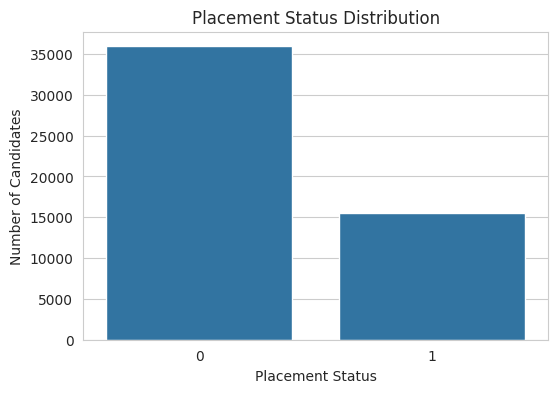

In [ ]:
# Plot
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

plt.figure(figsize=(6,4))
sns.countplot(data=JAPS_df, x='status')

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Candidates")

plt.show()

In [ ]:
JAPS_df['status'].value_counts()

,count
status,
0,35921
1,15579


###Gender Distribution

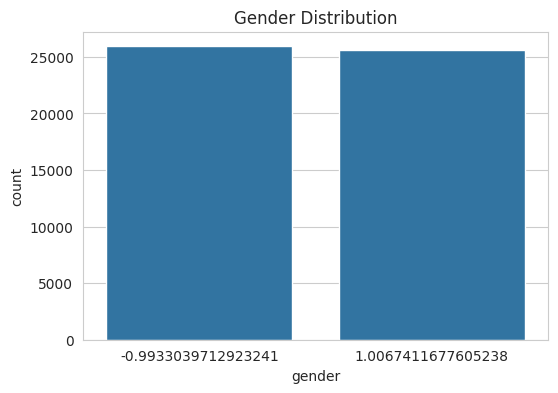

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=JAPS_df, x='gender')

plt.title("Gender Distribution")

plt.show()

###Interview Performance vs Placement

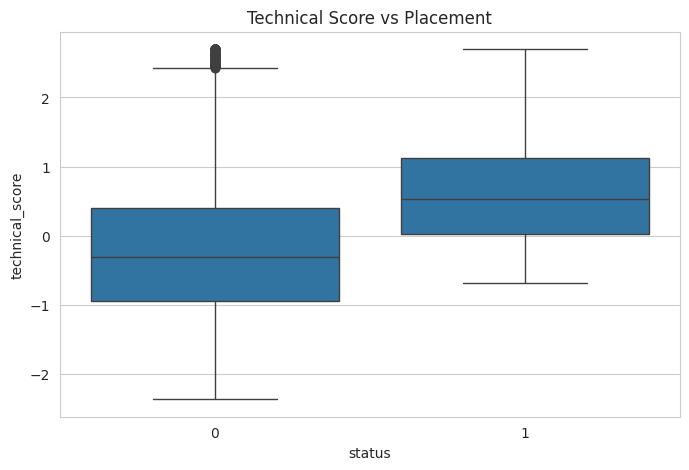

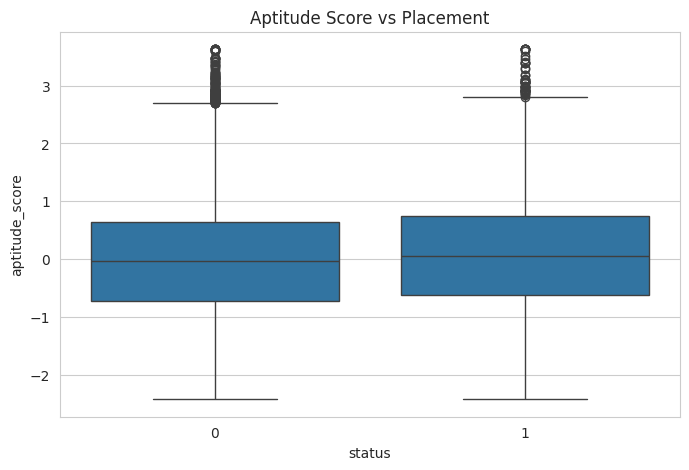

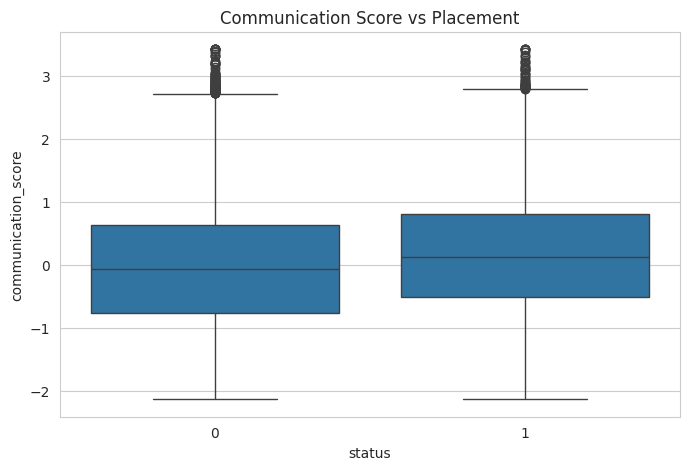

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=JAPS_df,
    x='status',
    y='technical_score'
)

plt.title("Technical Score vs Placement")

plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(
    data=JAPS_df,
    x='status',
    y='aptitude_score'
)

plt.title("Aptitude Score vs Placement")

plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(
    data=JAPS_df,
    x='status',
    y='communication_score'
)

plt.title("Communication Score vs Placement")

plt.show()

###Skills Match Percentage vs Placement

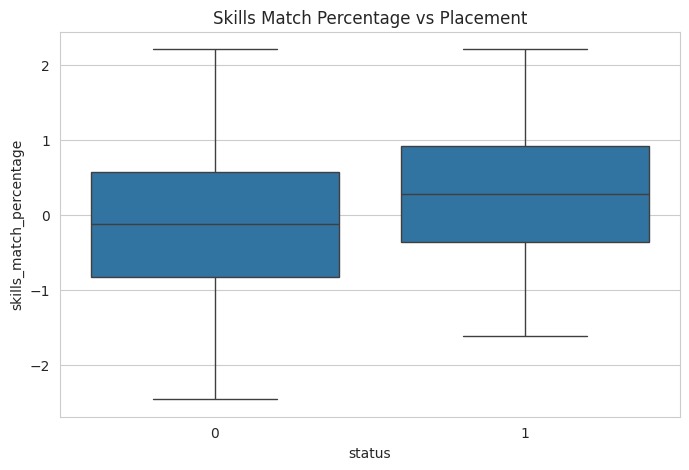

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=JAPS_df,
    x='status',
    y='skills_match_percentage'
)

plt.title("Skills Match Percentage vs Placement")

plt.show()

#####Candidates with higher skills match percentages are generally more likely to be placed.

###Company Tier vs Placement

In [ ]:
print(JAPS_df.columns)

Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'technical_score', 'aptitude_score',
       'communication_score', 'skills_match_percentage',
       'certifications_count', 'internship_experience', 'years_of_experience',
       'career_switch_willingness', 'relevant_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'job_role_match', 'competition_level',
       'bond_requirement', 'notice_period_days', 'layoff_history',
       'employment_gap_months', 'relocation_willingness', 'status',
       'degree_specialization_Electronics',
       'degree_specialization_Information Technology',
       'degree_specialization_Mechanical', 'degree_specialization_Others',
       'company_tier_Tier 2', 'company_tier_Tier 3'],
      dtype='object')


In [ ]:
# Create temporary column for visualization

JAPS_df['company_tier_eda'] = 'Tier 1'

JAPS_df.loc[
    JAPS_df['company_tier_Tier 2'] == 1,
    'company_tier_eda'
] = 'Tier 2'

JAPS_df.loc[
    JAPS_df['company_tier_Tier 3'] == 1,
    'company_tier_eda'
] = 'Tier 3'

In [ ]:
JAPS_df['company_tier_eda'].value_counts()

,count
company_tier_eda,
Tier 1,51500


In [ ]:
company_tier_placement = (
    JAPS_df.groupby('company_tier_eda')['status']
    .mean()
    * 100
)

company_tier_placement

,status
company_tier_eda,
Tier 1,30.250485


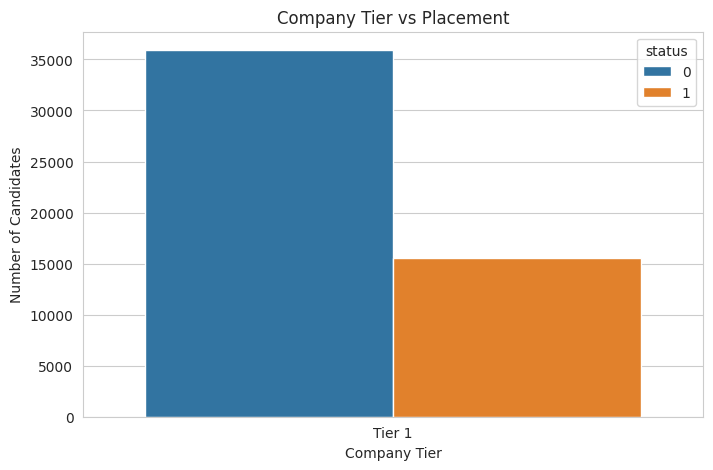

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=JAPS_df,
    x='company_tier_eda',
    hue='status'
)

plt.title("Company Tier vs Placement")

plt.xlabel("Company Tier")
plt.ylabel("Number of Candidates")

plt.show()

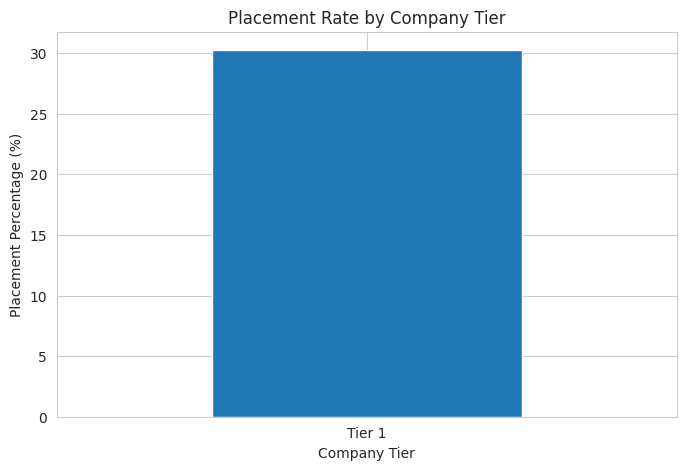

In [ ]:
plt.figure(figsize=(8,5))

company_tier_placement.plot(
    kind='bar'
)

plt.title("Placement Rate by Company Tier")

plt.xlabel("Company Tier")

plt.ylabel("Placement Percentage (%)")

plt.xticks(rotation=0)

plt.show()

###Years of Experience vs Placement

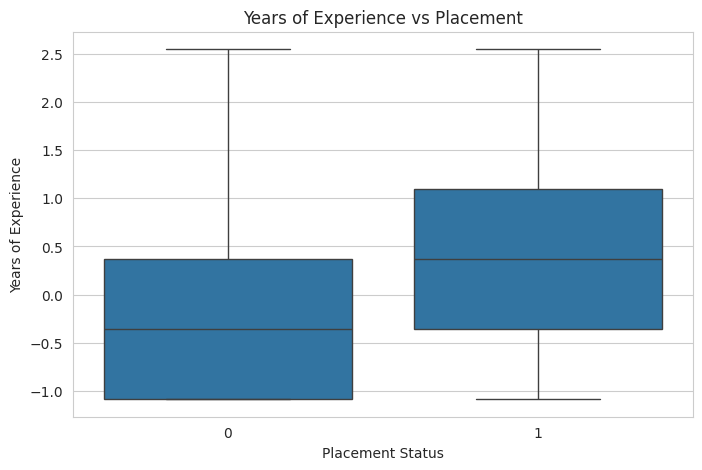

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=JAPS_df,
    x='status',
    y='years_of_experience'
)

plt.title("Years of Experience vs Placement")
plt.xlabel("Placement Status")
plt.ylabel("Years of Experience")

plt.show()

In [ ]:
experience_summary = (
    JAPS_df.groupby('status')['years_of_experience']
    .mean()
    .reset_index()
)

experience_summary

,status,years_of_experience
0,0,-0.218283
1,1,0.503301


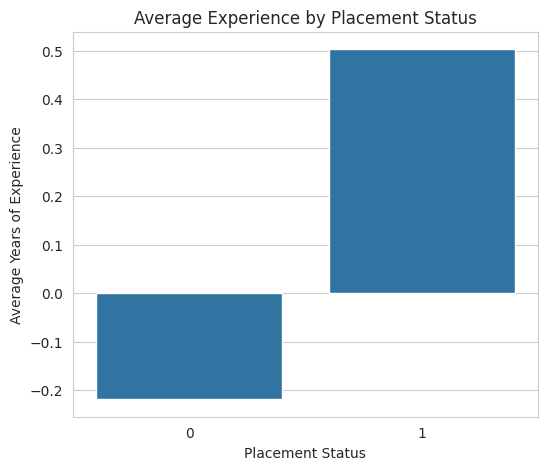

In [ ]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=experience_summary,
    x='status',
    y='years_of_experience'
)

plt.title("Average Experience by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Average Years of Experience")

plt.show()

In [ ]:
experience_probability = (
    JAPS_df.groupby('years_of_experience')['status']
    .mean()
    * 100
).reset_index()

experience_probability.head()

,years_of_experience,status
0,-1.086240,13.792208
1,-0.359228,24.021019
2,0.367783,36.089494
3,1.094794,49.118388
4,1.821806,57.718673


#####Here, the status column represents the placement probability (%) because it contains the mean of the encoded target (0 = Not Placed, 1 = Placed).

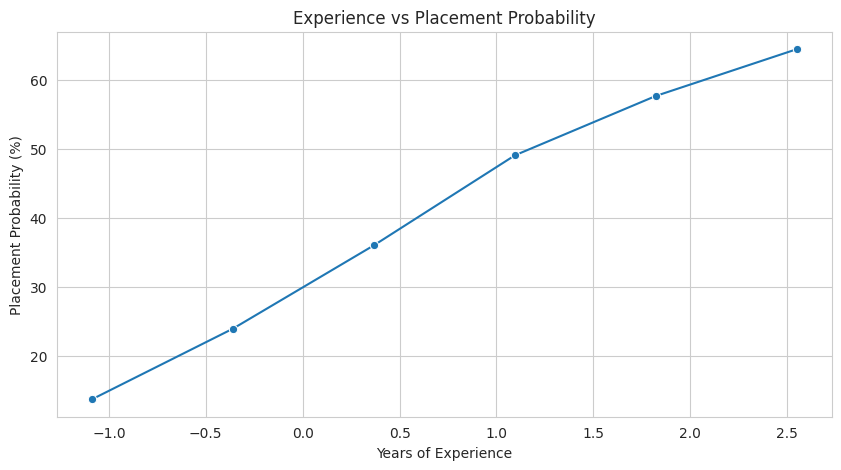

,years_of_experience,status
0,-1.086240,13.792208
1,-0.359228,24.021019
2,0.367783,36.089494
3,1.094794,49.118388
4,1.821806,57.718673
5,2.548817,64.490862


In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=experience_probability,
    x='years_of_experience',
    y='status',
    marker='o'
)

plt.title("Experience vs Placement Probability")
plt.xlabel("Years of Experience")
plt.ylabel("Placement Probability (%)")

plt.grid(True)

plt.show()
experience_probability

#####Placement probability generally increases with years of relevant experience.

#####Candidates with more professional experience are more likely to secure placements.

#####Experience appears to be an important predictor of placement outcomes and should be considered during model development.

In [ ]:
experience_probability = (
    JAPS_df.groupby('years_of_experience')['status']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

experience_probability

,years_of_experience,status,Percentage
0,-1.086240,0,86.207792
1,-1.086240,1,13.792208
2,-0.359228,0,75.978981
3,-0.359228,1,24.021019
4,0.367783,0,63.910506
5,0.367783,1,36.089494
6,1.094794,0,50.881612
7,1.094794,1,49.118388
8,1.821806,1,57.718673
9,1.821806,0,42.281327


###Competition Level vs Placement

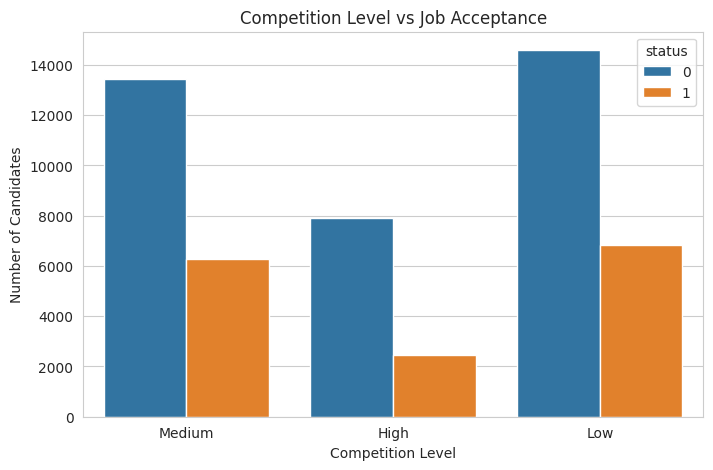

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=JAPS_df,
    x='competition_level',
    hue='status'
)

plt.title("Competition Level vs Job Acceptance")
plt.xlabel("Competition Level")
plt.ylabel("Number of Candidates")

plt.xticks(rotation=0)

plt.show()

In [ ]:
pd.crosstab(
    JAPS_df['competition_level'],
    JAPS_df['status']
)

status,0,1
competition_level,,
High,7909,2469
Low,14590,6824
Medium,13422,6286


###Correlation Analysis

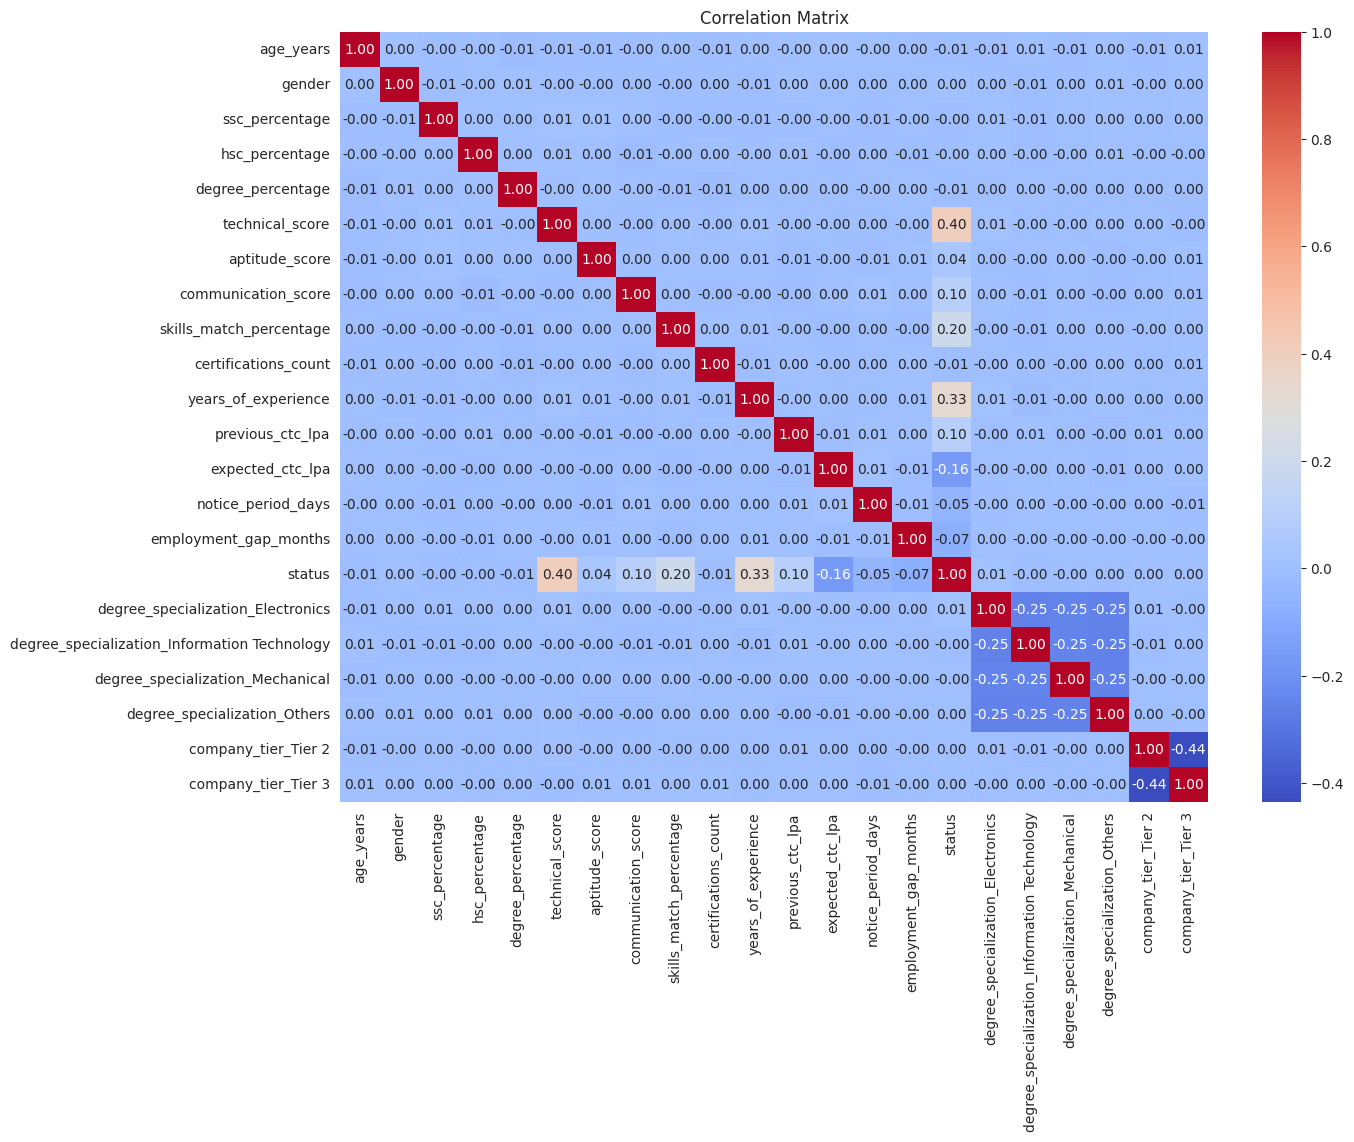

In [ ]:
plt.figure(figsize=(14,10))

correlation = JAPS_df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

###Distribution of Numerical Features

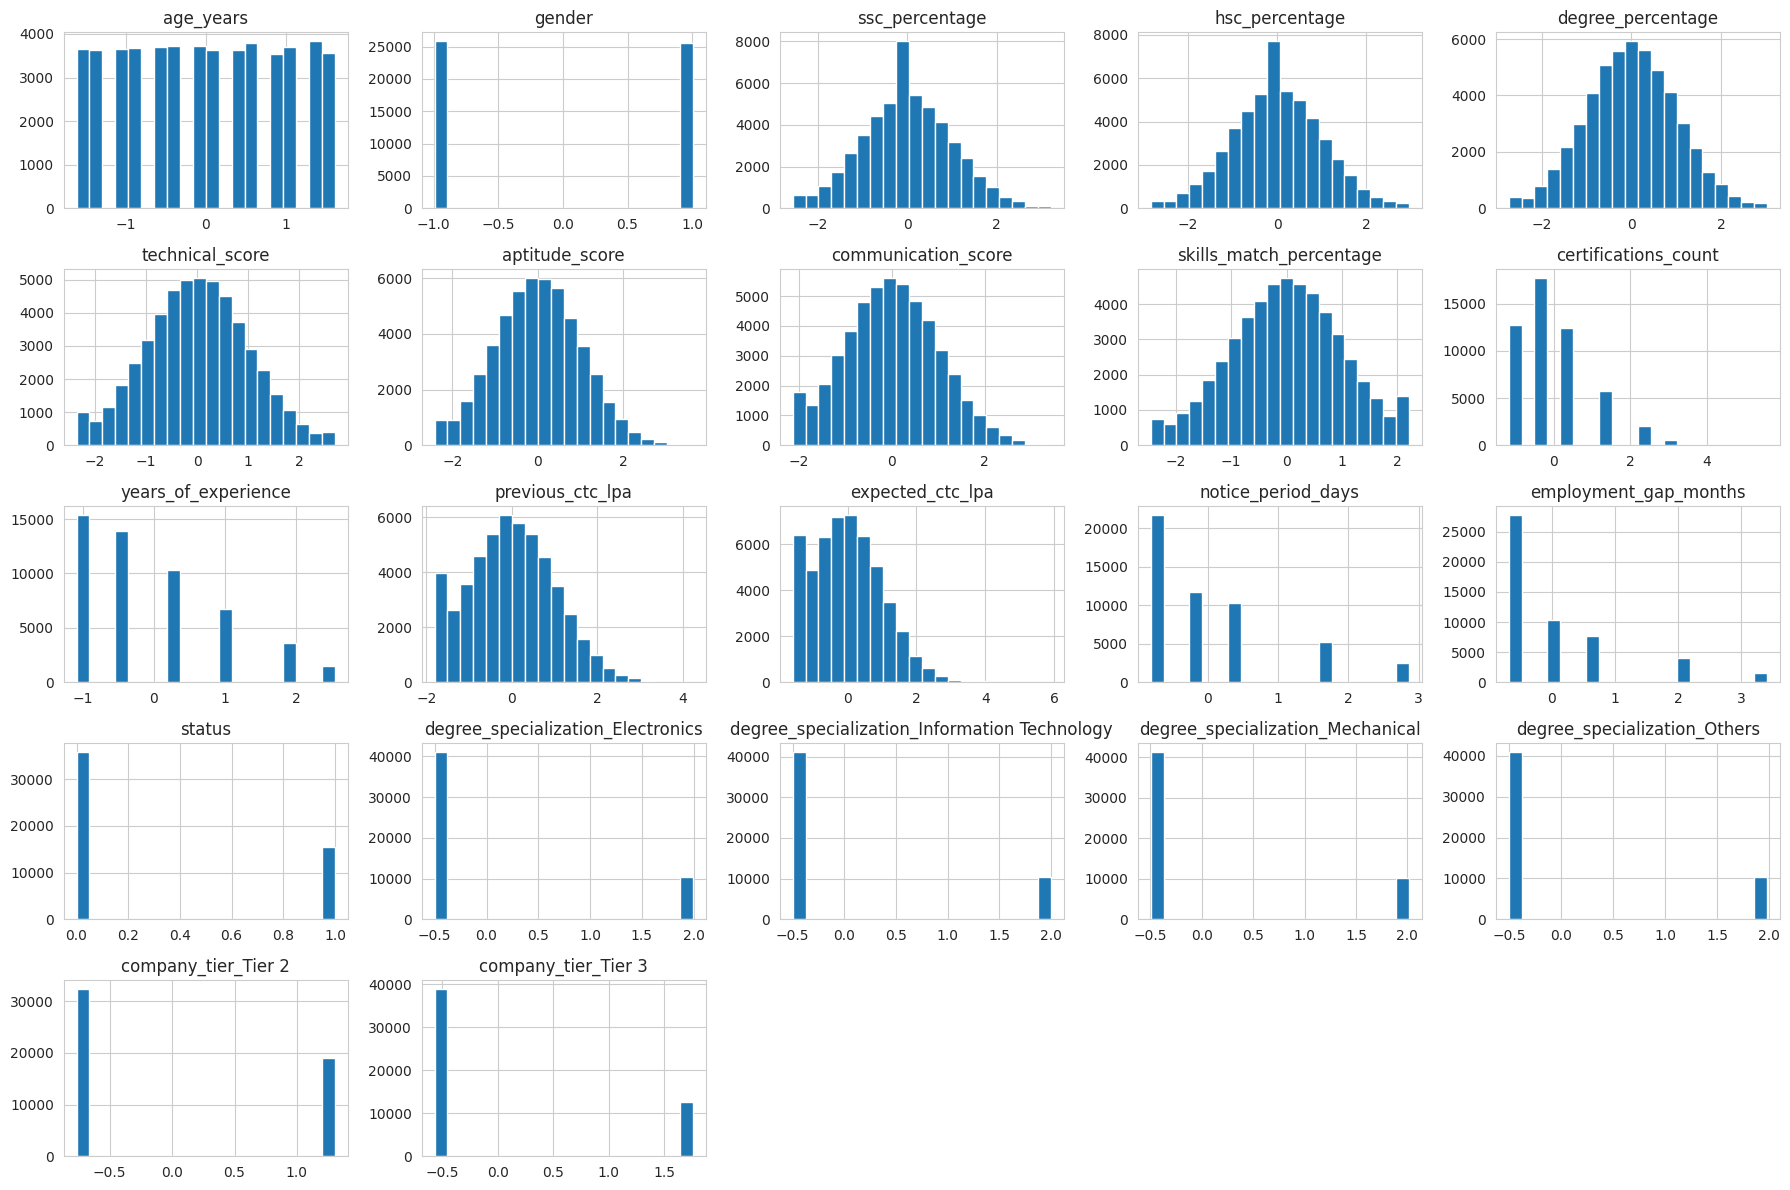

In [ ]:
JAPS_df.hist(
    figsize=(18,12),
    bins=20
)

plt.tight_layout()

plt.show()

###Placement Percentage

In [ ]:
placement_percentage = (
    JAPS_df['status']
    .value_counts(normalize=True)
    *100
)

print(placement_percentage)

status
0    69.749515
1    30.250485
Name: proportion, dtype: float64


#####Company Tier vs Placement: Visualization was not useful because the temporary company_tier_eda column classified all candidates as Tier 1.

#####Years of Experience vs Placement: Boxplot compares experience levels between placed and not-placed candidates to check whether experience impacts placement chances.

#####Competition Level vs Placement: Countplot shows placement success across Low, Medium, and High competition levels.

#####Correlation Analysis: Heatmap shows relationships between numerical features and their correlation with placement status.

#####Numerical Feature Distribution: Histograms display feature distributions, helping identify patterns, skewness, and outliers.

#####Placement Distribution: Dataset is imbalanced — 69.75% candidates are not placed and 30.25% candidates are placed.

#Step 5: Feature Engineering

###5.1 Experience Category

In [ ]:
def experience_category(exp):
    if exp == 0:
        return "Fresher"
    elif exp <= 3:
        return "Junior"
    else:
        return "Senior"

JAPS_df["experience_category"] = JAPS_df["years_of_experience"].apply(experience_category)

In [ ]:
JAPS_df[['years_of_experience','experience_category']].head(10)

,years_of_experience,experience_category
0,-0.359228,Junior
1,-1.086240,Junior
2,-0.359228,Junior
3,-1.086240,Junior
4,-1.086240,Junior
5,-0.359228,Junior
6,-0.359228,Junior
7,1.094794,Junior
8,0.367783,Junior
9,0.367783,Junior


In [ ]:
JAPS_df['experience_category'].value_counts()

,count
experience_category,
Junior,51500


###5.2 Academic Performance Bands

In [ ]:
JAPS_df['academic_average'] = (
    JAPS_df['ssc_percentage'] +
    JAPS_df['hsc_percentage'] +
    JAPS_df['degree_percentage']
) / 3

def academic_band(score):
    if score >= 75:
        return "Excellent"
    elif score >= 60:
        return "Good"
    elif score >= 50:
        return "Average"
    else:
        return "Poor"

JAPS_df["academic_band"] = JAPS_df["academic_average"].apply(academic_band)

In [ ]:
JAPS_df[['academic_average','academic_band']].head()

,academic_average,academic_band
0,0.383210,Poor
1,-0.439230,Poor
2,0.805073,Poor
3,0.433693,Poor
4,-0.352110,Poor


In [ ]:
JAPS_df['academic_band'].value_counts()

,count
academic_band,
Poor,51500


###5.3 Skills Match Level

In [ ]:
def skills_level(skill):
    if skill >= 80:
        return "High"
    elif skill >= 60:
        return "Medium"
    else:
        return "Low"

JAPS_df["skills_match_level"] = JAPS_df["skills_match_percentage"].apply(skills_level)

In [ ]:
JAPS_df[['skills_match_percentage','skills_match_level']].head()

,skills_match_percentage,skills_match_level
0,0.475780,Low
1,-0.052684,Low
2,0.129682,Low
3,-0.022133,Low
4,1.276681,Low


In [ ]:
JAPS_df['skills_match_level'].value_counts()

,count
skills_match_level,
Low,51500


###5.4 Interview Performance Category

In [ ]:
JAPS_df['interview_average'] = (
    JAPS_df['technical_score'] +
    JAPS_df['aptitude_score'] +
    JAPS_df['communication_score']
) / 3

def interview_category(score):
    if score >= 80:
        return "Excellent"
    elif score >= 65:
        return "Good"
    elif score >= 50:
        return "Average"
    else:
        return "Poor"

JAPS_df["interview_performance"] = JAPS_df["interview_average"].apply(interview_category)

In [ ]:
JAPS_df[['interview_average','interview_performance']].head()

,interview_average,interview_performance
0,0.528068,Poor
1,-0.375790,Poor
2,0.392614,Poor
3,-0.211836,Poor
4,-0.092397,Poor


In [ ]:
JAPS_df['interview_performance'].value_counts()

,count
interview_performance,
Poor,51500


###5.5 Placement Probability Score

In [ ]:
JAPS_df["placement_probability_score"] = (
    (JAPS_df["technical_score"] * 0.30) +
    (JAPS_df["aptitude_score"] * 0.20) +
    (JAPS_df["communication_score"] * 0.20) +
    (JAPS_df["skills_match_percentage"] * 0.20) +
    (JAPS_df["degree_percentage"] * 0.10)
)

In [ ]:
JAPS_df[['placement_probability_score']].head()

,placement_probability_score
0,0.355858
1,-0.216316
2,0.531805
3,-0.017501
4,0.299848


In [ ]:
JAPS_df['placement_probability_score'].describe()

,placement_probability_score
count,5.150000e+04
mean,-4.687857e-16
std,4.691068e-01
min,-1.878951e+00
25%,-3.199058e-01
50%,-1.309022e-03
75%,3.208956e-01
max,1.927113e+00


In [ ]:
new_features = [
    'experience_category',
    'academic_average',
    'academic_band',
    'skills_match_level',
    'interview_average',
    'interview_performance',
    'placement_probability_score'
]

JAPS_df[new_features].head()

,experience_category,academic_average,academic_band,skills_match_level,interview_average,interview_performance,placement_probability_score
0,Junior,0.383210,Poor,Low,0.528068,Poor,0.355858
1,Junior,-0.439230,Poor,Low,-0.375790,Poor,-0.216316
2,Junior,0.805073,Poor,Low,0.392614,Poor,0.531805
3,Junior,0.433693,Poor,Low,-0.211836,Poor,-0.017501
4,Junior,-0.352110,Poor,Low,-0.092397,Poor,0.299848


#Step 6.1: Save Cleaned Dataset as CSV

In [ ]:
JAPS_df.to_csv("/content/drive/MyDrive/Colab Notebooks/Project3_JAPS_Analysis&prediction/HR_Job_Placement_Cleaned_Dataset.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [ ]:
JAPS_Cleaned_df= pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Project3_JAPS_Analysis&prediction/HR_Job_Placement_Cleaned_Dataset.csv")

In [ ]:
JAPS_Cleaned_df.shape

(51500, 38)

In [ ]:
JAPS_Cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51500 entries, 0 to 51499
Data columns (total 38 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   age_years                                     51500 non-null  float64
 1   gender                                        51500 non-null  float64
 2   ssc_percentage                                51500 non-null  float64
 3   hsc_percentage                                51500 non-null  float64
 4   degree_percentage                             51500 non-null  float64
 5   technical_score                               51500 non-null  float64
 6   aptitude_score                                51500 non-null  float64
 7   communication_score                           51500 non-null  float64
 8   skills_match_percentage                       51500 non-null  float64
 9   certifications_count                          51500 non-null 

In [ ]:
from sqlalchemy import create_engine

In [ ]:
username='postgres'
password='pearlraj10'
port=5432
database_name='JAPSAnalysis&Prediction_db'
host_name='localhost'
engine=create_engine(f'postgresql+psycopg2://{username}:{password}@{host_name}:{port}/{database_name}')

In [ ]:
JAPS_Cleaned_df.to_sql('job_placement_data', con=engine, if_exists='replace', index=False,chunksize=10000,method='multi')

51500

In [ ]:
query = """
SELECT *
FROM job_placement_data
LIMIT 10;
"""

df = pd.read_sql(query, engine)

df

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,...,company_tier_Tier 2,company_tier_Tier 3,company_tier_eda,experience_category,academic_average,academic_band,skills_match_level,interview_average,interview_performance,placement_probability_score
0,-0.125568,1.006741,-0.635376,1.519267,0.265740,-0.827125,2.576075,-0.164746,0.475780,0.506481,...,-0.766388,1.760216,Tier 1,Junior,0.383210,Poor,Low,0.528068,Poor,0.355858
1,-0.870846,1.006741,-0.272108,-0.913519,-0.132062,0.329015,-0.948746,-0.507640,-0.052684,-0.337845,...,-0.766388,-0.568112,Tier 1,Junior,-0.439230,Poor,Low,-0.375790,Poor,-0.216316
2,1.364987,-0.993304,0.500596,-0.415750,2.330373,0.372630,-0.546106,1.351319,0.129682,-0.337845,...,-0.766388,1.760216,Tier 1,Junior,0.805073,Poor,Low,0.392614,Poor,0.531805
3,0.868135,1.006741,0.533154,0.541028,0.226896,0.913382,-0.300701,-1.248190,-0.022133,0.506481,...,1.304822,-0.568112,Tier 1,Junior,0.433693,Poor,Low,-0.211836,Poor,-0.017501
4,0.122857,1.006741,-1.225270,-0.808697,0.977636,0.021871,0.172139,-0.471201,1.276681,-0.337845,...,1.304822,-0.568112,Tier 1,Junior,-0.352110,Poor,Low,-0.092397,Poor,0.299848
5,1.364987,-0.993304,-1.203938,-0.761572,0.603646,1.437064,-1.785133,-1.864046,0.370516,-0.337845,...,1.304822,-0.568112,Tier 1,Junior,-0.453955,Poor,Low,-0.737372,Poor,-0.164249
6,-0.622420,-0.993304,1.057817,-0.319807,0.843730,1.445848,-1.694908,0.428174,0.508597,-0.337845,...,1.304822,-0.568112,Tier 1,Junior,0.527247,Poor,Low,0.059705,Poor,0.366500
7,-0.125568,-0.993304,-0.003824,-0.380008,0.204428,0.644848,-0.767360,1.037252,0.305986,-1.182172,...,-0.766388,-0.568112,Tier 1,Junior,-0.059801,Poor,Low,0.304914,Poor,0.329073
8,0.619709,-0.993304,-0.059840,0.863656,0.827400,0.865061,-0.136887,1.566826,-0.509206,1.350808,...,-0.766388,1.760216,Tier 1,Junior,0.543739,Poor,Low,0.765000,Poor,0.526405
9,-1.119272,-0.993304,0.124974,0.779092,-0.178954,-1.136500,-0.297291,-0.659985,1.796455,-1.182172,...,-0.766388,-0.568112,Tier 1,Junior,0.241704,Poor,Low,-0.697925,Poor,-0.191010


In [ ]:
query = """
SELECT technical_score,
status
FROM job_placement_data
ORDER BY technical_score DESC
LIMIT 10;
"""

pd.read_sql(query, engine)

,technical_score,status
0,2.696956,1
1,2.696956,1
2,2.696956,1
3,2.696956,1
4,2.696956,1
5,2.696956,1
6,2.696956,0
7,2.696956,1
8,2.696956,1
9,2.696956,0


#Step 7: Machine Learning Modeling

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix



In [ ]:
X = JAPS_Cleaned_df.drop('status', axis=1)
y = JAPS_Cleaned_df['status']

In [ ]:
y.value_counts()

,count
status,
0,35921
1,15579


####7.1 Feature Encoding

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [ ]:
categorical_columns = X.select_dtypes(include='object').columns
numerical_columns = X.select_dtypes(exclude='object').columns

In [ ]:
categorical_columns

Index(['internship_experience', 'career_switch_willingness',
       'relevant_experience', 'job_role_match', 'competition_level',
       'bond_requirement', 'layoff_history', 'relocation_willingness',
       'company_tier_eda', 'experience_category', 'academic_band',
       'skills_match_level', 'interview_performance'],
      dtype='object')

In [ ]:
numerical_columns

Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'technical_score', 'aptitude_score',
       'communication_score', 'skills_match_percentage',
       'certifications_count', 'years_of_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'notice_period_days', 'employment_gap_months',
       'degree_specialization_Electronics',
       'degree_specialization_Information Technology',
       'degree_specialization_Mechanical', 'degree_specialization_Others',
       'company_tier_Tier 2', 'company_tier_Tier 3', 'academic_average',
       'interview_average', 'placement_probability_score'],
      dtype='object')

####7.2 Preprocessing

In [ ]:
preprocessor = ColumnTransformer(transformers=[('num','passthrough',numerical_columns),
                                               ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_columns)])

####7.3 Machine Learning Models

####LogisticRegression

In [ ]:
lr_model = LogisticRegression(max_iter=1000)

In [ ]:
rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', lr_model)])
rf_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'technical_score', 'aptitude_score',
       'communication_score', 'skills_match_percentage',
       'certifications_count', 'years_of_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'notice_period_da...
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['internship_experience', 'career_switch_willingness',
       'relevant_experience', 'job_role_match', 'competition_level',
       'bond_requirement', 'layoff_history', 'relocation_willingness',
       'company_tier_eda', 'experience_category', 'academic_band',
       'skills_match_level', 'interview_performance'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

TRAINING PERFORMANCE
Accuracy : 0.8695631067961165

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.92      0.91     28737
           1       0.81      0.75      0.78     12463

    accuracy                           0.87     41200
   macro avg       0.85      0.83      0.84     41200
weighted avg       0.87      0.87      0.87     41200

TEST PERFORMANCE
Accuracy : 0.8671844660194175

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.92      0.91      7184
           1       0.80      0.75      0.77      3116

    accuracy                           0.87     10300
   macro avg       0.85      0.83      0.84     10300
weighted avg       0.87      0.87      0.87     10300



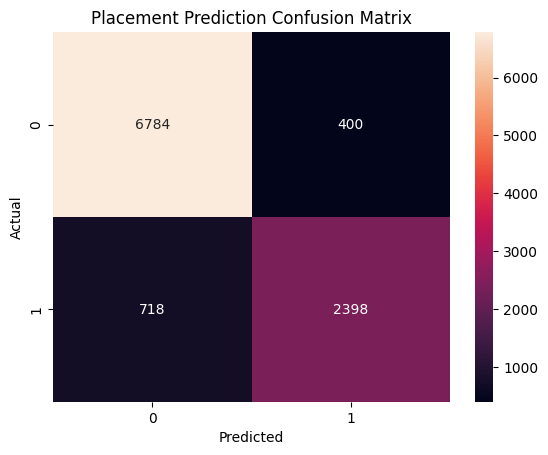

In [ ]:
y_train_pred = rf_pipeline.predict(X_train)
y_test_pred = rf_pipeline.predict(X_test)

# Train Evaluation

print("TRAINING PERFORMANCE")
print("Accuracy :", accuracy_score(y_train, y_train_pred))

print("\nClassification Report")
print(classification_report(y_train, y_train_pred))

# Test Evaluation

print("TEST PERFORMANCE")
print("Accuracy :", accuracy_score(y_test, y_test_pred))

print("\nClassification Report")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Placement Prediction Confusion Matrix")
plt.show()

###RandomForestClassifier

####Model 1

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200,random_state=42)

In [ ]:
rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', rf_model)])
rf_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'technical_score', 'aptitude_score',
       'communication_score', 'skills_match_percentage',
       'certifications_count', 'years_of_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'notice_period_da...
                                                  Index(['internship_experience', 'career_switch_willingness',
       'relevant_experience', 'job_role_match', 'competition_level',
       'bond_requirement', 'layoff_history', 'relocation_willingness',
       'company_tier_eda', 'experience_category', 'academic_band',
       'skills_match_level', 'interview_performance'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

TRAINING PERFORMANCE
Accuracy : 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28737
           1       1.00      1.00      1.00     12463

    accuracy                           1.00     41200
   macro avg       1.00      1.00      1.00     41200
weighted avg       1.00      1.00      1.00     41200

TEST PERFORMANCE
Accuracy : 0.8914563106796116

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      7184
           1       0.86      0.77      0.81      3116

    accuracy                           0.89     10300
   macro avg       0.88      0.86      0.87     10300
weighted avg       0.89      0.89      0.89     10300



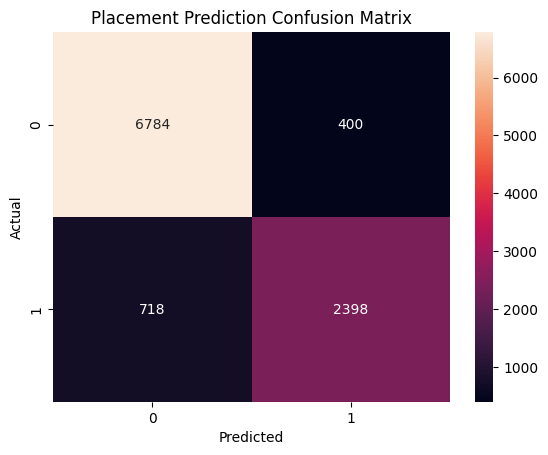

In [ ]:
y_train_pred = rf_pipeline.predict(X_train)
y_test_pred = rf_pipeline.predict(X_test)

# Train Evaluation

print("TRAINING PERFORMANCE")
print("Accuracy :", accuracy_score(y_train, y_train_pred))

print("\nClassification Report")
print(classification_report(y_train, y_train_pred))

# Test Evaluation

print("TEST PERFORMANCE")
print("Accuracy :", accuracy_score(y_test, y_test_pred))

print("\nClassification Report")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Placement Prediction Confusion Matrix")
plt.show()

####Model 2

In [ ]:
rf_model =RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=42)

In [ ]:
rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', rf_model)])
rf_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'technical_score', 'aptitude_score',
       'communication_score', 'skills_match_percentage',
       'certifications_count', 'years_of_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'notice_period_da...
                                                  Index(['internship_experience', 'career_switch_willingness',
       'relevant_experience', 'job_role_match', 'competition_level',
       'bond_requirement', 'layoff_history', 'relocation_willingness',
       'company_tier_eda', 'experience_category', 'academic_band',
       'skills_match_level', 'interview_performance'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

TRAINING PERFORMANCE
Accuracy : 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28737
           1       1.00      1.00      1.00     12463

    accuracy                           1.00     41200
   macro avg       1.00      1.00      1.00     41200
weighted avg       1.00      1.00      1.00     41200

TEST PERFORMANCE
Accuracy : 0.8884466019417476

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7184
           1       0.86      0.75      0.80      3116

    accuracy                           0.89     10300
   macro avg       0.88      0.85      0.86     10300
weighted avg       0.89      0.89      0.89     10300



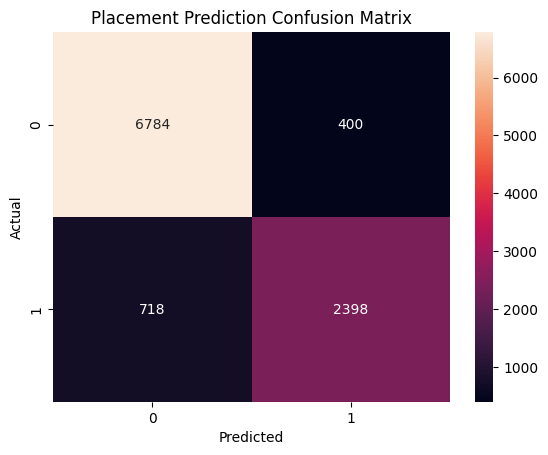

In [ ]:
y_train_pred = rf_pipeline.predict(X_train)
y_test_pred = rf_pipeline.predict(X_test)

# Train Evaluation

print("TRAINING PERFORMANCE")
print("Accuracy :", accuracy_score(y_train, y_train_pred))

print("\nClassification Report")
print(classification_report(y_train, y_train_pred))

# Test Evaluation

print("TEST PERFORMANCE")
print("Accuracy :", accuracy_score(y_test, y_test_pred))

print("\nClassification Report")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Placement Prediction Confusion Matrix")
plt.show()

####Model 3

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200,max_depth=10,min_samples_split=20,min_samples_leaf=10,max_features="sqrt",random_state=42)

In [ ]:
rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', rf_model)])
rf_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'technical_score', 'aptitude_score',
       'communication_score', 'skills_match_percentage',
       'certifications_count', 'years_of_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'notice_period_da...
       'relevant_experience', 'job_role_match', 'competition_level',
       'bond_requirement', 'layoff_history', 'relocation_willingness',
       'company_tier_eda', 'experience_category', 'academic_band',
       'skills_match_level', 'interview_performance'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=10,
                                        min_samples_split=20, n_estimators=200,
                                        random_state=42))])

TRAINING PERFORMANCE
Accuracy : 0.892378640776699

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.96      0.93     28737
           1       0.89      0.74      0.81     12463

    accuracy                           0.89     41200
   macro avg       0.89      0.85      0.87     41200
weighted avg       0.89      0.89      0.89     41200

TEST PERFORMANCE
Accuracy : 0.8679611650485437

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      7184
           1       0.85      0.68      0.76      3116

    accuracy                           0.87     10300
   macro avg       0.86      0.82      0.83     10300
weighted avg       0.87      0.87      0.86     10300



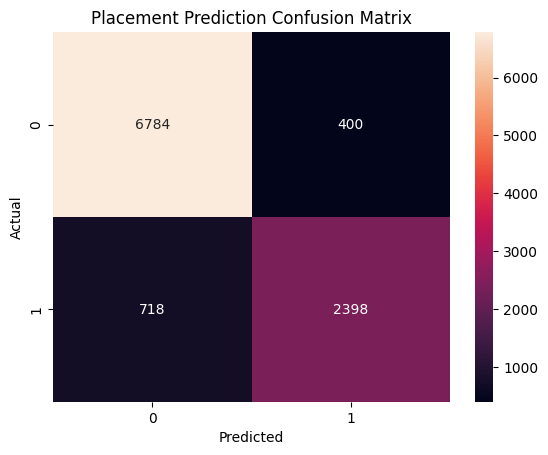

In [ ]:
y_train_pred = rf_pipeline.predict(X_train)
y_test_pred = rf_pipeline.predict(X_test)

# Train Evaluation

print("TRAINING PERFORMANCE")
print("Accuracy :", accuracy_score(y_train, y_train_pred))

print("\nClassification Report")
print(classification_report(y_train, y_train_pred))

# Test Evaluation

print("TEST PERFORMANCE")
print("Accuracy :", accuracy_score(y_test, y_test_pred))

print("\nClassification Report")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Placement Prediction Confusion Matrix")
plt.show()

###DecisionTreeClassifier

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

In [ ]:
rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', dt_model)])
rf_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'technical_score', 'aptitude_score',
       'communication_score', 'skills_match_percentage',
       'certifications_count', 'years_of_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'notice_period_da...
                                                  Index(['internship_experience', 'career_switch_willingness',
       'relevant_experience', 'job_role_match', 'competition_level',
       'bond_requirement', 'layoff_history', 'relocation_willingness',
       'company_tier_eda', 'experience_category', 'academic_band',
       'skills_match_level', 'interview_performance'],
      dtype='object'))])),
                ('model', DecisionTreeClassifier(random_state=42))])

TRAINING PERFORMANCE
Accuracy : 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28737
           1       1.00      1.00      1.00     12463

    accuracy                           1.00     41200
   macro avg       1.00      1.00      1.00     41200
weighted avg       1.00      1.00      1.00     41200

TEST PERFORMANCE
Accuracy : 0.8302912621359223

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      7184
           1       0.72      0.73      0.72      3116

    accuracy                           0.83     10300
   macro avg       0.80      0.80      0.80     10300
weighted avg       0.83      0.83      0.83     10300



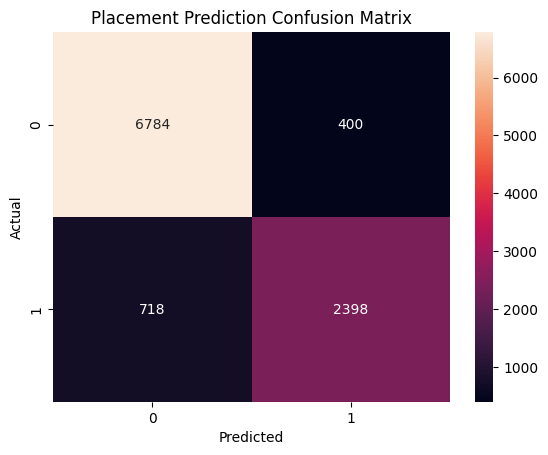

In [ ]:
y_train_pred = rf_pipeline.predict(X_train)
y_test_pred = rf_pipeline.predict(X_test)

# Train Evaluation

print("TRAINING PERFORMANCE")
print("Accuracy :", accuracy_score(y_train, y_train_pred))

print("\nClassification Report")
print(classification_report(y_train, y_train_pred))

# Test Evaluation

print("TEST PERFORMANCE")
print("Accuracy :", accuracy_score(y_test, y_test_pred))

print("\nClassification Report")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Placement Prediction Confusion Matrix")
plt.show()

###XGBClassifier

In [ ]:
xgb_model = XGBClassifier(n_estimators=200,learning_rate=0.05,random_state=42)

In [ ]:
rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', xgb_model)])
rf_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'technical_score', 'aptitude_score',
       'communication_score', 'skills_match_percentage',
       'certifications_count', 'years_of_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'notice_period_da...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

TRAINING PERFORMANCE
Accuracy : 0.9384223300970874

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     28737
           1       0.90      0.89      0.90     12463

    accuracy                           0.94     41200
   macro avg       0.93      0.93      0.93     41200
weighted avg       0.94      0.94      0.94     41200

TEST PERFORMANCE
Accuracy : 0.9049514563106796

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7184
           1       0.85      0.84      0.84      3116

    accuracy                           0.90     10300
   macro avg       0.89      0.89      0.89     10300
weighted avg       0.90      0.90      0.90     10300



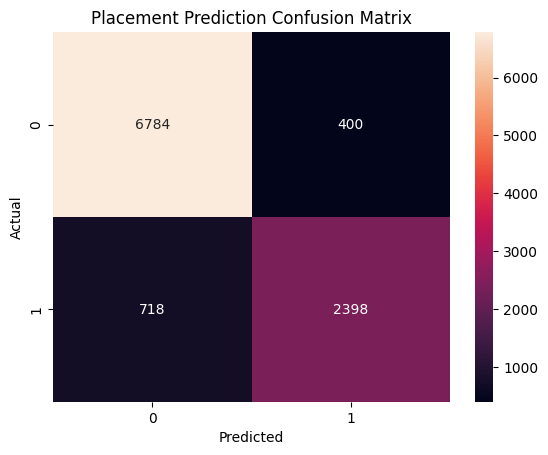

In [ ]:
y_train_pred = rf_pipeline.predict(X_train)
y_test_pred = rf_pipeline.predict(X_test)

# Train Evaluation

print("TRAINING PERFORMANCE")
print("Accuracy :", accuracy_score(y_train, y_train_pred))

print("\nClassification Report")
print(classification_report(y_train, y_train_pred))

# Test Evaluation

print("TEST PERFORMANCE")
print("Accuracy :", accuracy_score(y_test, y_test_pred))

print("\nClassification Report")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Placement Prediction Confusion Matrix")
plt.show()

In [ ]:
# Get trained Random Forest model
rf_model = rf_pipeline.named_steps["model"]

# Get feature names after encoding
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Create feature importance dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display Top 15 important features
importance_df.head(15)

,Feature,Importance
5,num__technical_score,0.241736
10,num__years_of_experience,0.178324
23,num__placement_probability_score,0.157952
22,num__interview_average,0.062723
8,num__skills_match_percentage,0.055639
12,num__expected_ctc_lpa,0.045989
31,cat__job_role_match_Not Matched,0.036819
30,cat__job_role_match_Matched,0.034450
25,cat__internship_experience_Yes,0.022929
24,cat__internship_experience_No,0.021313


##Logistic Regression
####Logistic Regression achieved 86.72% accuracy on unseen test data with an 84% weighted F1-score. The model demonstrated strong stability with only a 0.23% difference between training and testing accuracy, indicating excellent generalization. Logistic Regression serves as a reliable baseline model for predicting candidate placement outcomes.

#Step 8: Analyst Tasks (EDA & ML Analytics) – Candidate Performance Analysis

###Step 8.1: Academic Scores vs Placement Outcome

In [ ]:
academic_analysis = JAPS_Cleaned_df.groupby('status')[['ssc_percentage','hsc_percentage','degree_percentage','academic_average']].mean()

academic_analysis

,ssc_percentage,hsc_percentage,degree_percentage,academic_average
status,,,,
0,0.002802,0.001414,0.004986,0.003067
1,-0.006461,-0.003260,-0.011496,-0.007072


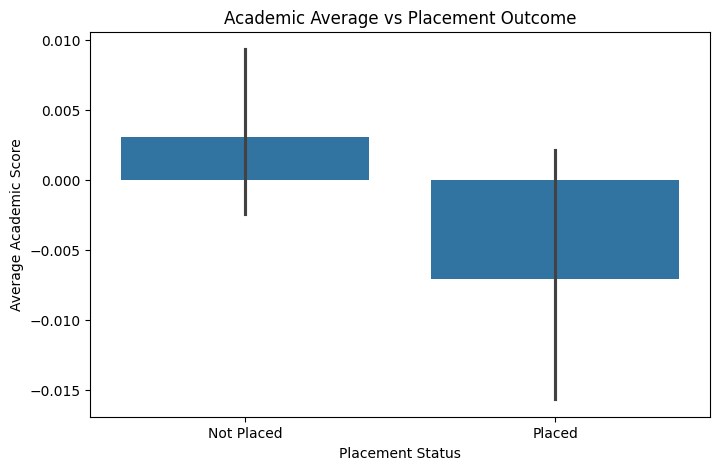

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=JAPS_Cleaned_df,x='status',y='academic_average')
plt.xticks([0,1],['Not Placed','Placed'])
plt.title("Academic Average vs Placement Outcome")
plt.xlabel("Placement Status")
plt.ylabel("Average Academic Score")
plt.show()

#####Academic scores are an important supporting factor, but skills and interview performance also influence final selection.

###Step 8.2: Skills Match vs Interview Performance

In [ ]:
skills_analysis = JAPS_Cleaned_df.groupby('status')[['skills_match_percentage','interview_average']].mean()

skills_analysis

,skills_match_percentage,interview_average
status,,
0,-0.130299,-0.118997
1,0.300436,0.274376


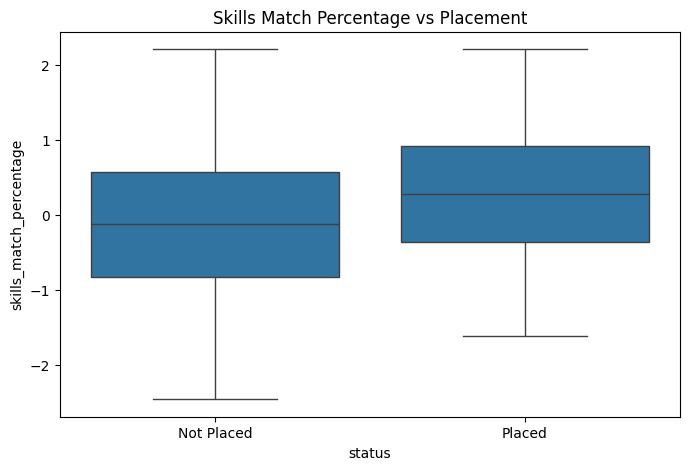

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=JAPS_Cleaned_df,x='status',y='skills_match_percentage')
plt.xticks([0,1],['Not Placed','Placed'])
plt.title("Skills Match Percentage vs Placement")
plt.show()

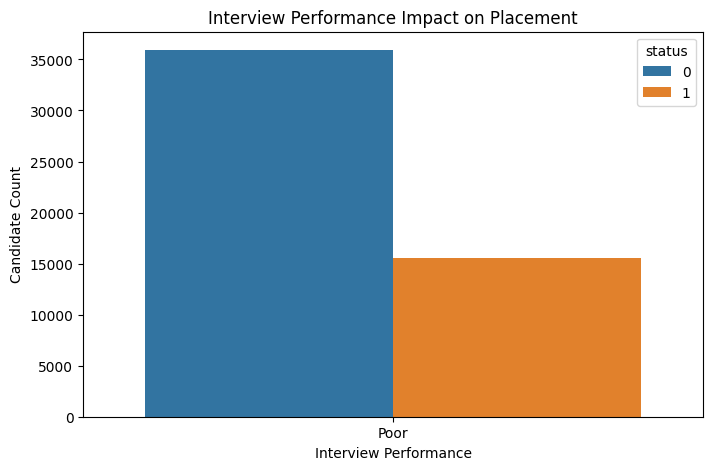

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=JAPS_Cleaned_df,x='interview_performance',hue='status')
plt.title("Interview Performance Impact on Placement")
plt.xlabel("Interview Performance")
plt.ylabel("Candidate Count")

plt.show()

###Step 8.3: Certification Impact on Job Acceptance

In [ ]:
certification_analysis = JAPS_Cleaned_df.groupby('status')['certifications_count'].mean()

certification_analysis

,certifications_count
status,
0,0.003402
1,-0.007843


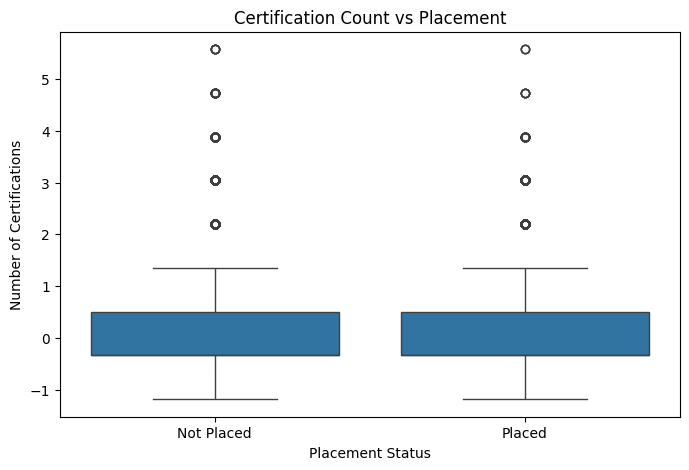

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=JAPS_Cleaned_df,x='status',y='certifications_count')
plt.xticks([0,1],['Not Placed','Placed'])
plt.title("Certification Count vs Placement")
plt.xlabel("Placement Status")
plt.ylabel("Number of Certifications")
plt.show()

In [ ]:
JAPS_Cleaned_df.groupby('certifications_count')['status'].mean().reset_index()

,certifications_count,status
0,-1.182172,0.305968
1,-0.337845,0.302085
2,0.506481,0.299896
3,1.350808,0.305091
4,2.195135,0.308407
5,3.039461,0.257443
6,3.883788,0.296610
7,4.728115,0.151515
8,5.572442,0.333333


####Candidate placement success is mainly influenced by skill-job alignment, interview performance, and technical capabilities. Academic scores provide a strong foundation, while certifications offer additional value. The analysis indicates that candidates combining strong academics, relevant skills, and good interview performance have a higher probability of job acceptance.

###Placement & Acceptance Analysis – JAPS Candidate Analytics

####step 8.4:Acceptance Rate by Company Tier

In [ ]:
company_tier_analysis = (JAPS_Cleaned_df.groupby('company_tier_eda')['status'].mean().reset_index())
company_tier_analysis['acceptance_rate_%'] = (company_tier_analysis['status'] * 100)

company_tier_analysis

,company_tier_eda,status,acceptance_rate_%
0,Tier 1,0.302505,30.250485


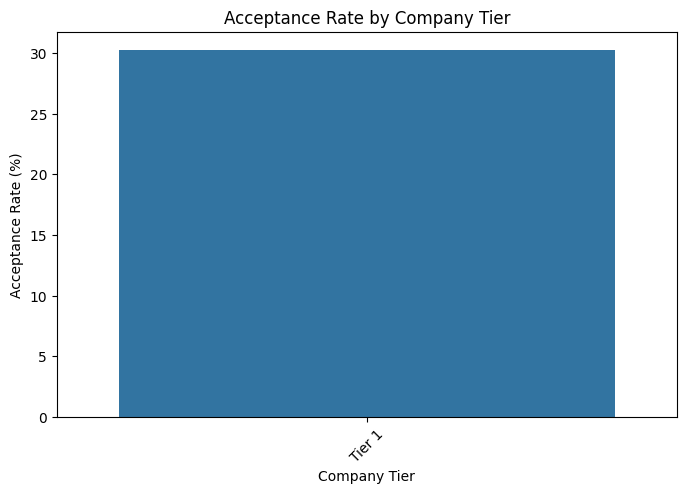

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=company_tier_analysis,x='company_tier_eda',y='acceptance_rate_%')
plt.title("Acceptance Rate by Company Tier")
plt.xlabel("Company Tier")
plt.ylabel("Acceptance Rate (%)")
plt.xticks(rotation=45)
plt.show()

####Step 8.5: Experience vs Placement Success

In [ ]:
experience_analysis = (JAPS_Cleaned_df.groupby('experience_category')['status'].mean().reset_index())
experience_analysis['placement_rate_%'] = (experience_analysis['status'] * 100)

experience_analysis

,experience_category,status,placement_rate_%
0,Junior,0.302505,30.250485


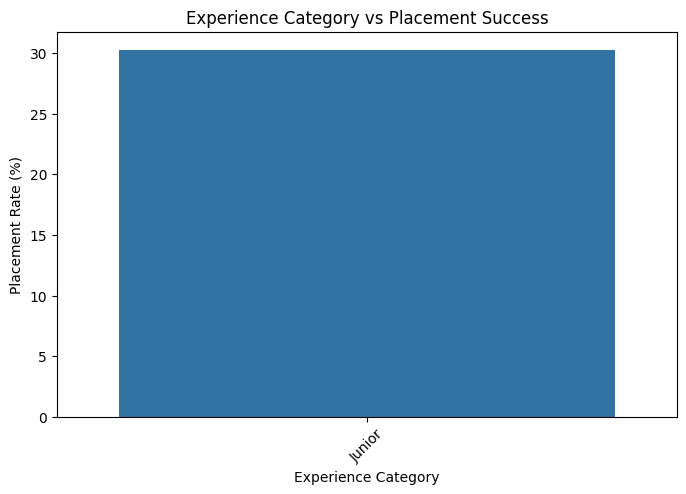

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=experience_analysis,x='experience_category',y='placement_rate_%')
plt.title("Experience Category vs Placement Success")
plt.xlabel("Experience Category")
plt.ylabel("Placement Rate (%)")
plt.xticks(rotation=45)

plt.show()

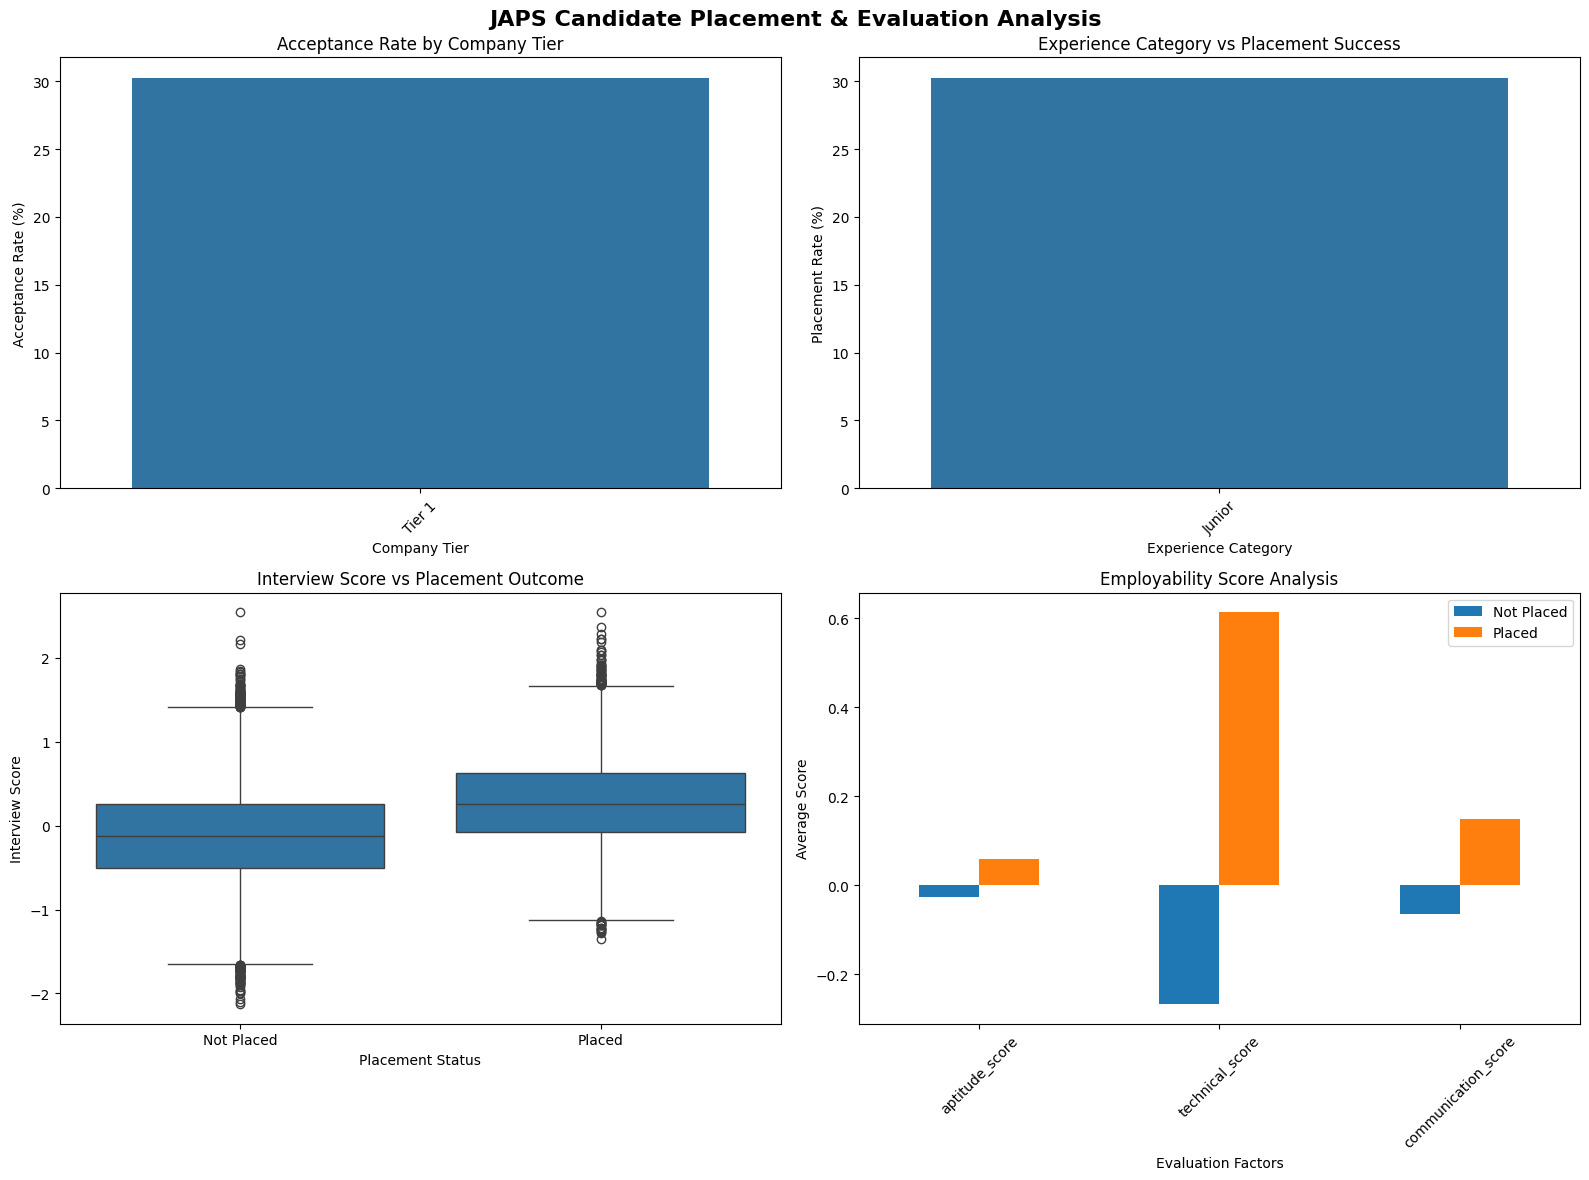

In [ ]:

plt.figure(figsize=(16,12))
plt.subplot(2,2,1)

company_tier_analysis = (
    JAPS_Cleaned_df
    .groupby('company_tier_eda')['status']
    .mean()
    .reset_index()
)

company_tier_analysis['acceptance_rate_%'] = (
    company_tier_analysis['status'] * 100
)

sns.barplot(
    data=company_tier_analysis,
    x='company_tier_eda',
    y='acceptance_rate_%'
)

plt.title("Acceptance Rate by Company Tier")
plt.xlabel("Company Tier")
plt.ylabel("Acceptance Rate (%)")
plt.xticks(rotation=45)
plt.subplot(2,2,2)

experience_analysis = (
    JAPS_Cleaned_df
    .groupby('experience_category')['status']
    .mean()
    .reset_index()
)

experience_analysis['placement_rate_%'] = (
    experience_analysis['status'] * 100
)

sns.barplot(
    data=experience_analysis,
    x='experience_category',
    y='placement_rate_%'
)

plt.title("Experience Category vs Placement Success")
plt.xlabel("Experience Category")
plt.ylabel("Placement Rate (%)")
plt.xticks(rotation=45)
plt.subplot(2,2,3)

sns.boxplot(
    data=JAPS_Cleaned_df,
    x='status',
    y='interview_average'
)

plt.xticks(
    [0,1],
    ['Not Placed','Placed']
)

plt.title("Interview Score vs Placement Outcome")
plt.xlabel("Placement Status")
plt.ylabel("Interview Score")

plt.subplot(2,2,4)

employability_analysis = (
    JAPS_Cleaned_df
    .groupby('status')
    [
        [
            'aptitude_score',
            'technical_score',
            'communication_score'
        ]
    ]
    .mean()
)

employability_analysis.T.plot(
    kind='bar',
    ax=plt.gca()
)

plt.title("Employability Score Analysis")
plt.xlabel("Evaluation Factors")
plt.ylabel("Average Score")

plt.xticks(rotation=45)
plt.legend(
    ['Not Placed','Placed']
)

# Main Title
plt.suptitle(
    "JAPS Candidate Placement & Evaluation Analysis",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

####Placement success is not determined by a single factor. Candidates with strong employability scores, relevant experience, high interview performance, and better skill alignment have a significantly higher probability of job acceptance.

##Interview & Evaluation Analysis

####Step 8.6: Interview Score vs Placement Probability

In [ ]:
interview_analysis = (JAPS_Cleaned_df.groupby('status')[['interview_average','placement_probability_score']].mean())

interview_analysis

,interview_average,placement_probability_score
status,,
0,-0.118997,-0.123576
1,0.274376,0.284933


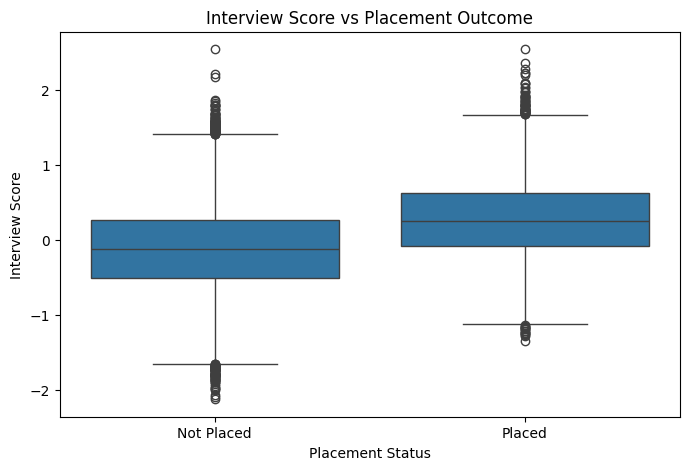

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=JAPS_Cleaned_df,
    x='status',
    y='interview_average'
)

plt.xticks(
    [0,1],
    ['Not Placed','Placed']
)

plt.title(
    "Interview Score vs Placement Outcome"
)

plt.xlabel(
    "Placement Status"
)

plt.ylabel(
    "Interview Score"
)

plt.show()

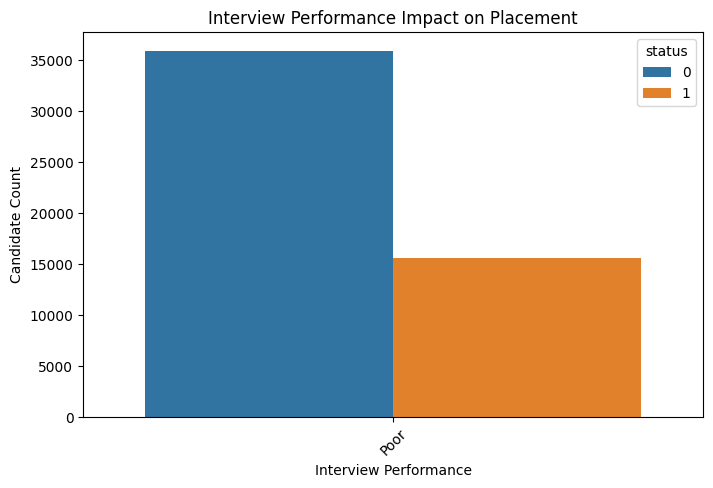

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=JAPS_Cleaned_df,
    x='interview_performance',
    hue='status'
)

plt.title(
    "Interview Performance Impact on Placement"
)

plt.xlabel(
    "Interview Performance"
)

plt.ylabel(
    "Candidate Count"
)

plt.xticks(rotation=45)

plt.show()

####Interview score has a strong positive relationship with job acceptance. Candidates who perform well in interviews have a higher probability of placement.

###Step 8.7: Employability Test Score Analysis

In [ ]:
employability_analysis = (
    JAPS_Cleaned_df
    .groupby('status')
    [
        [
            'technical_score',
            'aptitude_score',
            'communication_score'
        ]
    ]
    .mean()
)

employability_analysis

,technical_score,aptitude_score,communication_score
status,,,
0,-0.266162,-0.025792,-0.065038
1,0.613697,0.059470,0.149961


<Figure size 900x500 with 0 Axes>

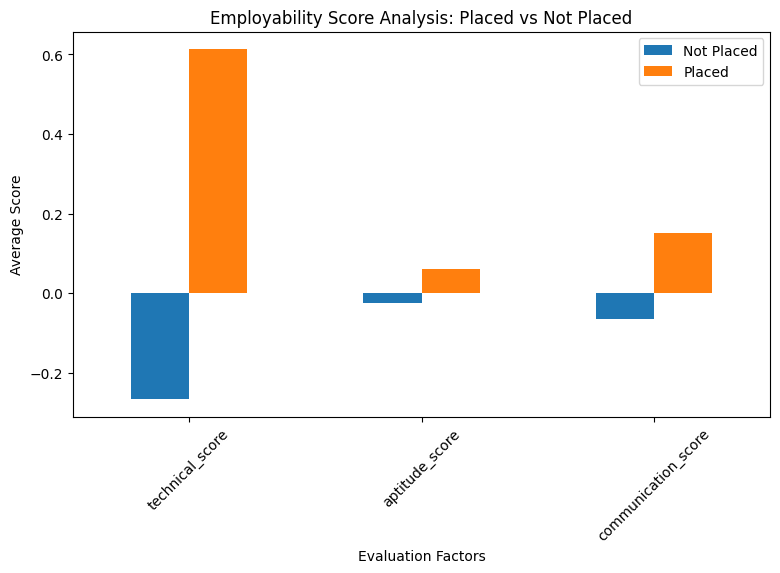

In [ ]:
plt.figure(figsize=(9,5))
employability_analysis.T.plot(kind='bar',figsize=(9,5))
plt.title("Employability Score Analysis: Placed vs Not Placed")
plt.xlabel("Evaluation Factors")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.legend(['Not Placed','Placed'])

plt.show()

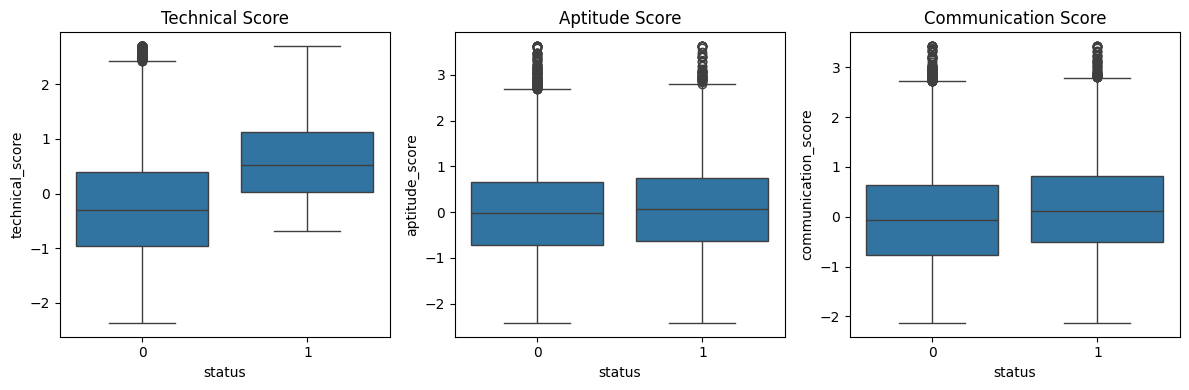

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(data=JAPS_Cleaned_df,x='status',y='technical_score')
plt.title("Technical Score")
plt.subplot(1,3,2)
sns.boxplot(data=JAPS_Cleaned_df,x='status',y='aptitude_score')
plt.title("Aptitude Score")


plt.subplot(1,3,3)
sns.boxplot(data=JAPS_Cleaned_df,x='status',y='communication_score')
plt.title("Communication Score")
plt.tight_layout()

plt.show()

####Interview performance and employability test scores are among the strongest predictors of job acceptance. Candidates with higher technical capability, problem-solving ability, communication skills, and interview scores demonstrate significantly higher placement probability.